# TRABAJO PRÁCTICO FINAL
## Pipeline Integral de Ciencia de Datos: Análisis, Modelado y Evaluación Aplicados

| Campo | Detalle |
|---|---|
| **Materia** | Introducción a la Ciencia de Datos |
| **Dataset** | Nómina de Funcionarios Públicos — 003-CÁMARA DE DIPUTADOS — Paraguay 2025 |
| **Fecha** | Mayo 2026 |
| **Autores** | Bethania Avila · Alfredo Coronel |

---

## Descripción del Proyecto

Pipeline completo sobre la **nómina de la Cámara de Diputados 2025** (13 archivos CSV mensuales). Cubre carga, limpieza, EDA, clasificación supervisada, regresión supervisada y clustering no supervisado.

### Preguntas orientadoras

| Etapa | Pregunta |
|---|---|
| **EDA** | ¿Cómo se distribuye el gasto? ¿Existe brecha de género? ¿Hay estacionalidad? |
| **Clasificación** | ¿Es posible predecir si un funcionario está en el segmento de alto ingreso anual? |
| **Regresión** | ¿Cuánto devengará un funcionario dado su cargo, antigüedad y tipo de contrato? |
| **Clustering 1** | ¿Qué perfiles de empleados existen según antigüedad y nivel salarial? |
| **Clustering 2** | ¿Qué patrones de gasto por objeto existen y qué registros son anómalos? |


In [1]:
import sys, os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [2]:
# Ruta base de datos — ajustar si los CSV están en otra ubicación
BASE_PATH = r'C:\Users\betha\eda_maestria\Nomina 2025'
ENTIDAD   = '003-CÁMARA DE DIPUTADOS'   # valor exacto en descripcionEntidad

MESES = {
    1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr',  5:'May',  6:'Jun',
    7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic', 13:'Ag13'
}

NOMBRES_OG = {
    111: 'sueldo',            112: 'dietas',
    113: 'g_representacion',  114: 'aguinaldo',
    123: 'rem_extraord',      131: 'sub_familiar',
    133: 'bonificaciones',    137: 'gratificaciones',
    142: 'contrat_salud',     144: 'jornales',
    145: 'honorarios',        199: 'otros_gastos',
    232: 'viaticos'
}

def fmt_mill(x, pos=None):
    return f'{x/1_000_000:.0f}M'

def fmt_gs(x, pos=None):
    return f'{int(x):,}'.replace(',', '.')


---
# ETAPA 1 — Carga, Exploración Inicial y Limpieza de Datos
**Puntos: 25**

Fuente: Portal de Datos Abiertos del Ministerio de Hacienda de Paraguay.
13 archivos CSV mensuales, uno por cada período de nómina 2025.
Se filtra únicamente la entidad **003-CÁMARA DE DIPUTADOS**.

### Diagnóstico anticipado
- `horasCatedra`: 100% nula → descartar
- `lugar`: ~95% nula → imputar con 'N/A' (solo relevante para comisionados)
- `cargo`: ~0.6% nulo → imputar con 'SIN CARGO'
- **Corte 13**: archivo de ajuste/aguinaldo anual (mes=13). Sus registros **no se eliminan** del dataset: permanecen en `df` pero se **excluyen** de todos los cálculos salariales (`df[mes != 13]`) para evitar doble conteo en la masa salarial mensual
- Montos ya en formato numérico (int64), sin necesidad de conversión de string


## 1.1 Comprensión del Problema

### Variables clave del dataset

| Columna | Descripción |
|---|---|
| `montoPresupuestado` | Monto bruto asignado en el presupuesto |
| `montoDevengado` | Monto efectivamente devengado (días trabajados, sin descuentos) |
| `cargo` | Nivel jerárquico: ASESOR, DIRECTOR, MIEMBROS, TÉCNICO I, etc. |
| `tipoPersonal` | PER = Permanente · CON = Contratado · COM = Comisionado |
| `conceptoGasto` | Objeto del gasto: sueldo, bonificaciones, dietas, viáticos… |
| `sexo` | M / F |
| `fechaIngreso` | Fecha de ingreso al servicio civil |
| `codigoPersona` | Número de cédula del funcionario (identificador único) |
| `codigoObjetoGasto` | Código numérico del concepto de gasto |


In [3]:
# 1.2 Carga de datos — todos los archivos CSV del período 2025
dfs = []
for folder in sorted(os.listdir(BASE_PATH)):
    folder_path = os.path.join(BASE_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    for fname in sorted(os.listdir(folder_path)):
        if not fname.endswith('.csv'):
            continue
        ruta   = os.path.join(folder_path, fname)
        df_mes = pd.read_csv(ruta, low_memory=False, encoding='latin-1')
        df_mes = df_mes[df_mes['descripcionEntidad'].str.contains(ENTIDAD, na=False)]
        dfs.append(df_mes)
        print(f'  {fname}: {len(df_mes):>5} registros de {ENTIDAD}')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal combinado: {df_raw.shape[0]:,} filas  ×  {df_raw.shape[1]} columnas')


  nomina_2025-01.csv:  3146 registros de 003-CÁMARA DE DIPUTADOS


  nomina_2025-02.csv:  3221 registros de 003-CÁMARA DE DIPUTADOS


  nomina_2025-03.csv:  3875 registros de 003-CÁMARA DE DIPUTADOS


  nomina_2025-04.csv:  3453 registros de 003-CÁMARA DE DIPUTADOS


  nomina_2025-05.csv:  3469 registros de 003-CÁMARA DE DIPUTADOS


...

  nomina_2025-09.csv:  3504 registros de 003-CÁMARA DE DIPUTADOS


  nomina_2025-10.csv:  3565 registros de 003-CÁMARA DE DIPUTADOS


  nomina_2025-11.csv:  3558 registros de 003-CÁMARA DE DIPUTADOS


  nomina_2025-12.csv:  3561 registros de 003-CÁMARA DE DIPUTADOS


  nomina_2025-13.csv:  3765 registros de 003-CÁMARA DE DIPUTADOS

Total combinado: 45,594 filas  ×  40 columnas


In [4]:
# 1.3 Vista previa y estructura
display(df_raw[['mes','descripcionEntidad','cargo','tipoPersonal',
                'sexo','montoPresupuestado','montoDevengado',
                'conceptoGasto','codigoPersona']].head(5))
print('\nTipos de dato relevantes:')
print(df_raw[['montoPresupuestado','montoDevengado','fechaIngreso',
              'cargo','tipoPersonal','sexo']].dtypes)


,mes,descripcionEntidad,cargo,tipoPersonal,sexo,montoPresupuestado,montoDevengado,conceptoGasto,codigoPersona
0,1,003-CÁMARA DE DIPUTADOS,TECNICO (I),PER,M,1200000,1200000,133-BONIFICACIONES,4807992
1,1,003-CÁMARA DE DIPUTADOS,TECNICO (I),PER,F,8300000,8300000,111-SUELDOS,1738083
2,1,003-CÁMARA DE DIPUTADOS,MIEMBROS,PER,M,5293160,5293160,113-GASTOS DE REPRESENTACIÓN,3769244
3,1,003-CÁMARA DE DIPUTADOS,TECNICO (I),PER,M,800000,800000,133-BONIFICACIONES,713479
4,1,003-CÁMARA DE DIPUTADOS,ASIST. TEC. ADMINISTRATIVO,PER,M,4500000,4500000,111-SUELDOS,4283945



Tipos de dato relevantes:
montoPresupuestado    int64
montoDevengado        int64
fechaIngreso            str
cargo                   str
tipoPersonal            str
sexo                    str
dtype: object


In [5]:
# 1.4 Diagnóstico de valores nulos
nulos     = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
res_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': nulos_pct})
print('=== Columnas con valores nulos ===')
display(res_nulos[res_nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False))


=== Columnas con valores nulos ===


,Nulos,% Nulos
horasCatedra,45594,100.00
lugar,43340,95.06
linea,8983,19.70
cargo,288,0.63


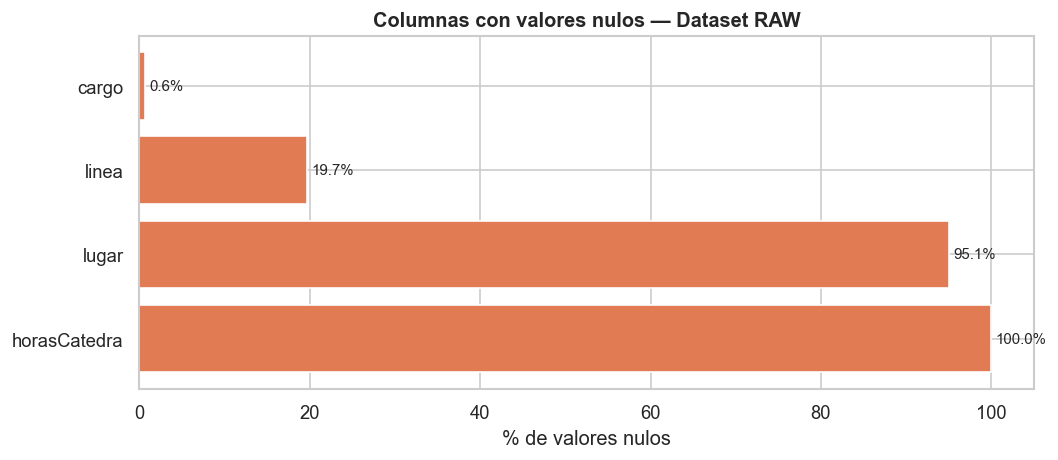

In [6]:
# Visualización de nulos
cols_nulas = res_nulos[res_nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cols_nulas.index, cols_nulas['% Nulos'], color='#e07b54', edgecolor='white')
ax.set_xlabel('% de valores nulos')
ax.set_title('Columnas con valores nulos — Dataset RAW', fontweight='bold')
for bar, val in zip(bars, cols_nulas['% Nulos']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


In [7]:
# 1.5 Duplicados y distribución por mes
n_dup = df_raw.duplicated().sum()
print(f'Filas 100% duplicadas: {n_dup:,}')
print('\nRegistros por mes (raw):')
print(df_raw.groupby('mes').size().rename(index=MESES).to_string())


Filas 100% duplicadas: 0

Registros por mes (raw):
mes
Ene     3146
Feb     3221
Mar     3875
Abr     3453
May     3469
Jun     3463
Jul     3489
Ago     3525
Sep     3504
Oct     3565
Nov     3558
Dic     3561
Ag13    3765


In [8]:
# 1.5b Análisis del corte 13 — ¿Qué concepto de gasto tienen los registros anulados?
df_mes13 = df_raw[df_raw['mes'] == 13].copy()
print(f'=== Registros del corte 13 (mes=13): {len(df_mes13):,} ===')
print()

# Distribución por concepto de gasto
print('Distribución por conceptoGasto:')
cg_13 = df_mes13['conceptoGasto'].value_counts()
display(pd.DataFrame({
    'Concepto': cg_13.index,
    'Registros': cg_13.values,
    '% del total': (cg_13.values / len(df_mes13) * 100).round(1)
}))

print()
# Montos promedio y total por concepto
print('Monto total devengado por concepto (mes=13):')
monto_13 = (
    df_mes13.groupby('conceptoGasto')['montoDevengado']
    .agg(['sum','mean','count'])
    .rename(columns={'sum':'Total (Gs.)','mean':'Promedio (Gs.)','count':'N'})
    .sort_values('Total (Gs.)', ascending=False)
)
monto_13['Total (M Gs.)']   = (monto_13['Total (Gs.)']   / 1e6).round(1)
monto_13['Promedio (M Gs.)']= (monto_13['Promedio (Gs.)'] / 1e6).round(2)
display(monto_13[['N','Total (M Gs.)','Promedio (M Gs.)']])


=== Registros del corte 13 (mes=13): 3,765 ===

Distribución por conceptoGasto:


,Concepto,Registros,% del total
0,114-AGUINALDO,1886,50.1
1,133-BONIFICACIONES,731,19.4
2,144-JORNALES,410,10.9
3,145-HONORARIOS PROFESIONALES,330,8.8
4,123-REMUNERACIÓN EXTRAORDINARIA,267,7.1
5,137-GRATIFICACIONES POR SERVICIOS ESPECIALES,138,3.7
6,142-CONTRATACIÓN DE PERSONAL DE SALUD,2,0.1
7,199-OTROS GASTOS DEL PERSONAL,1,0.0



Monto total devengado por concepto (mes=13):


,N,Total (M Gs.),Promedio (M Gs.)
conceptoGasto,,,
114-AGUINALDO,1886,15983.5,8.47
145-HONORARIOS PROFESIONALES,330,1380.0,4.18
133-BONIFICACIONES,731,1106.6,1.51
144-JORNALES,410,1080.2,2.63
137-GRATIFICACIONES POR SERVICIOS ESPECIALES,138,154.1,1.12
123-REMUNERACIÓN EXTRAORDINARIA,267,71.1,0.27
142-CONTRATACIÓN DE PERSONAL DE SALUD,2,9.0,4.50
199-OTROS GASTOS DEL PERSONAL,1,1.8,1.79


In [9]:
# 1.6 Anomalías en montos
print('=== Diagnóstico de montos ===')
print(f'  Presupuestado < 0   : {(df_raw["montoPresupuestado"] < 0).sum():,}')
print(f'  Devengado < 0       : {(df_raw["montoDevengado"] < 0).sum():,}')
zero_dev = (df_raw["montoDevengado"] == 0).sum()
print(f'  Devengado = 0       : {zero_dev:,}  ({zero_dev/len(df_raw)*100:.1f}%)')
print(f'  Devengado > Presup. : {(df_raw["montoDevengado"] > df_raw["montoPresupuestado"]).sum():,}')
print('\nTop 5 montos devengados:')
display(df_raw.nlargest(5, 'montoDevengado')[
    ['nombres','apellidos','cargo','mes','conceptoGasto','montoDevengado']])


=== Diagnóstico de montos ===
  Presupuestado < 0   : 0
  Devengado < 0       : 0
  Devengado = 0       : 23  (0.1%)
  Devengado > Presup. : 0

Top 5 montos devengados:


,nombres,apellidos,cargo,mes,conceptoGasto,montoDevengado
23876,RUBEN DARIO,MACIEL CUELLA,DIRECTOR GENERAL,7,199-OTROS GASTOS DEL PERSONAL,507592800
22942,DARIO DOMINGO SAVIO,RIOS EGUSQUIZA,COORDINADOR,7,199-OTROS GASTOS DEL PERSONAL,457708265
23149,MAURICIO DEJESUS,AGUILERA CORONEL,ASESOR,7,199-OTROS GASTOS DEL PERSONAL,368784000
22245,ARCADIO,CABRERA CABRAL,DIRECTOR GENERAL,7,199-OTROS GASTOS DEL PERSONAL,330960000
21593,ABEL CARLOS JAVIER,CROTTA FLEITAS,ASESOR,7,199-OTROS GASTOS DEL PERSONAL,324093000


In [10]:
# 1.7 Limpieza y normalización
df = df_raw.copy()

# Eliminar duplicados exactos (filas 100% iguales)
# Nota: el corte 13 (mes=13, aguinaldo) NO es un duplicado — se mantiene en df
# pero se excluye de los análisis salariales con df[df['mes'] != 13]
df = df.drop_duplicates()

# Fechas y antigüedad
df['fechaIngreso']     = pd.to_datetime(df['fechaIngreso'], errors='coerce')
df['antiguedad_anios'] = (pd.Timestamp('2025-12-31') - df['fechaIngreso']).dt.days / 365.25

# Normalizar texto categórico
for col in ['cargo', 'tipoPersonal', 'sexo', 'discapacidad', 'conceptoGasto']:
    df[col] = df[col].astype(str).str.strip().str.upper()

# Imputar nulos categóricos
df['cargo']        = df['cargo'].replace('NAN', 'SIN CARGO').fillna('SIN CARGO')
df['lugar']        = df['lugar'].fillna('N/A')
df['horasCatedra'] = df['horasCatedra'].fillna(0)

# Columnas derivadas
df['diferencia_gs'] = df['montoPresupuestado'] - df['montoDevengado']
df['mes_label']     = df['mes'].map(MESES)

print(f'Dataset limpio: {df.shape[0]:,} filas  ×  {df.shape[1]} columnas')
print('\nNulos residuales en columnas clave:')
print(df[['montoPresupuestado','montoDevengado','cargo','tipoPersonal','sexo']].isnull().sum())


Dataset limpio: 45,594 filas  ×  43 columnas



Nulos residuales en columnas clave:
montoPresupuestado    0
montoDevengado        0
cargo                 0
tipoPersonal          0
sexo                  0
dtype: int64


In [11]:
# 1.8 Resumen de calidad del dato
print('=== RESUMEN DE CALIDAD ===')
print(f'  Filas raw             : {len(df_raw):,}')
print(f'  Filas limpias         : {len(df):,}')
print(f'  Duplicados removidos  : {len(df_raw)-len(df):,}  (corte 13 + exactos)')
print(f'  Funcionarios únicos   : {df["codigoPersona"].nunique():,}')
print(f'  Rango mensual         : mes 1 a mes {df["mes"].max()}')
print(f'  Tipos de personal     : {sorted(df["tipoPersonal"].unique())}')
print(f'  Conceptos de gasto    : {df["conceptoGasto"].nunique()}')
print(f'  Cargos distintos      : {df["cargo"].nunique()}')


=== RESUMEN DE CALIDAD ===


  Filas raw             : 45,594
  Filas limpias         : 45,594
  Duplicados removidos  : 0  (corte 13 + exactos)
  Funcionarios únicos   : 2,539
  Rango mensual         : mes 1 a mes 13
  Tipos de personal     : ['COM', 'CON', 'PER']
  Conceptos de gasto    : 13
  Cargos distintos      : 38


---
# ETAPA 2 — Análisis Exploratorio de Datos (EDA)
**Puntos: 20**

Se analizan 6 dimensiones:
1. Estadística descriptiva y distribución salarial
2. Composición de la plantilla (tipo personal, sexo)
3. Brecha salarial por sexo
4. Evolución mensual de la masa salarial
5. Concentración del gasto (Curva de Lorenz / Gini)
6. Correlaciones entre variables numéricas


In [12]:
# 2.1 Estadística descriptiva
cols_mon = ['montoPresupuestado', 'montoDevengado', 'diferencia_gs']
desc     = df[cols_mon].describe()
print('=== Estadística descriptiva (valores en millones Gs.) ===')
display(desc.map(lambda x: f'{x/1e6:.2f} M'))

for col in ['montoPresupuestado', 'montoDevengado']:
    s = df[col]
    print(f'\n{col}')
    print(f'  Media    : {s.mean()/1e6:>10.2f} M')
    print(f'  Mediana  : {s.median()/1e6:>10.2f} M')
    print(f'  Desvío   : {s.std()/1e6:>10.2f} M')
    print(f'  Máximo   : {s.max()/1e6:>10.2f} M')
    print(f'  Skewness : {s.skew():>10.3f}  -> distribución muy asimétrica a la derecha')


=== Estadística descriptiva (valores en millones Gs.) ===


,montoPresupuestado,montoDevengado,diferencia_gs
count,0.05 M,0.05 M,0.05 M
mean,5.78 M,5.77 M,0.01 M
std,7.47 M,7.47 M,0.28 M
min,0.01 M,0.00 M,0.00 M
25%,2.00 M,2.00 M,0.00 M
50%,4.50 M,4.50 M,0.00 M
75%,7.10 M,7.10 M,0.00 M
max,507.59 M,507.59 M,19.30 M



montoPresupuestado
  Media    :       5.78 M
  Mediana  :       4.50 M
  Desvío   :       7.47 M
  Máximo   :     507.59 M
  Skewness :     22.003  -> distribución muy asimétrica a la derecha

montoDevengado
  Media    :       5.77 M
  Mediana  :       4.50 M
  Desvío   :       7.47 M
  Máximo   :     507.59 M
  Skewness :     22.017  -> distribución muy asimétrica a la derecha


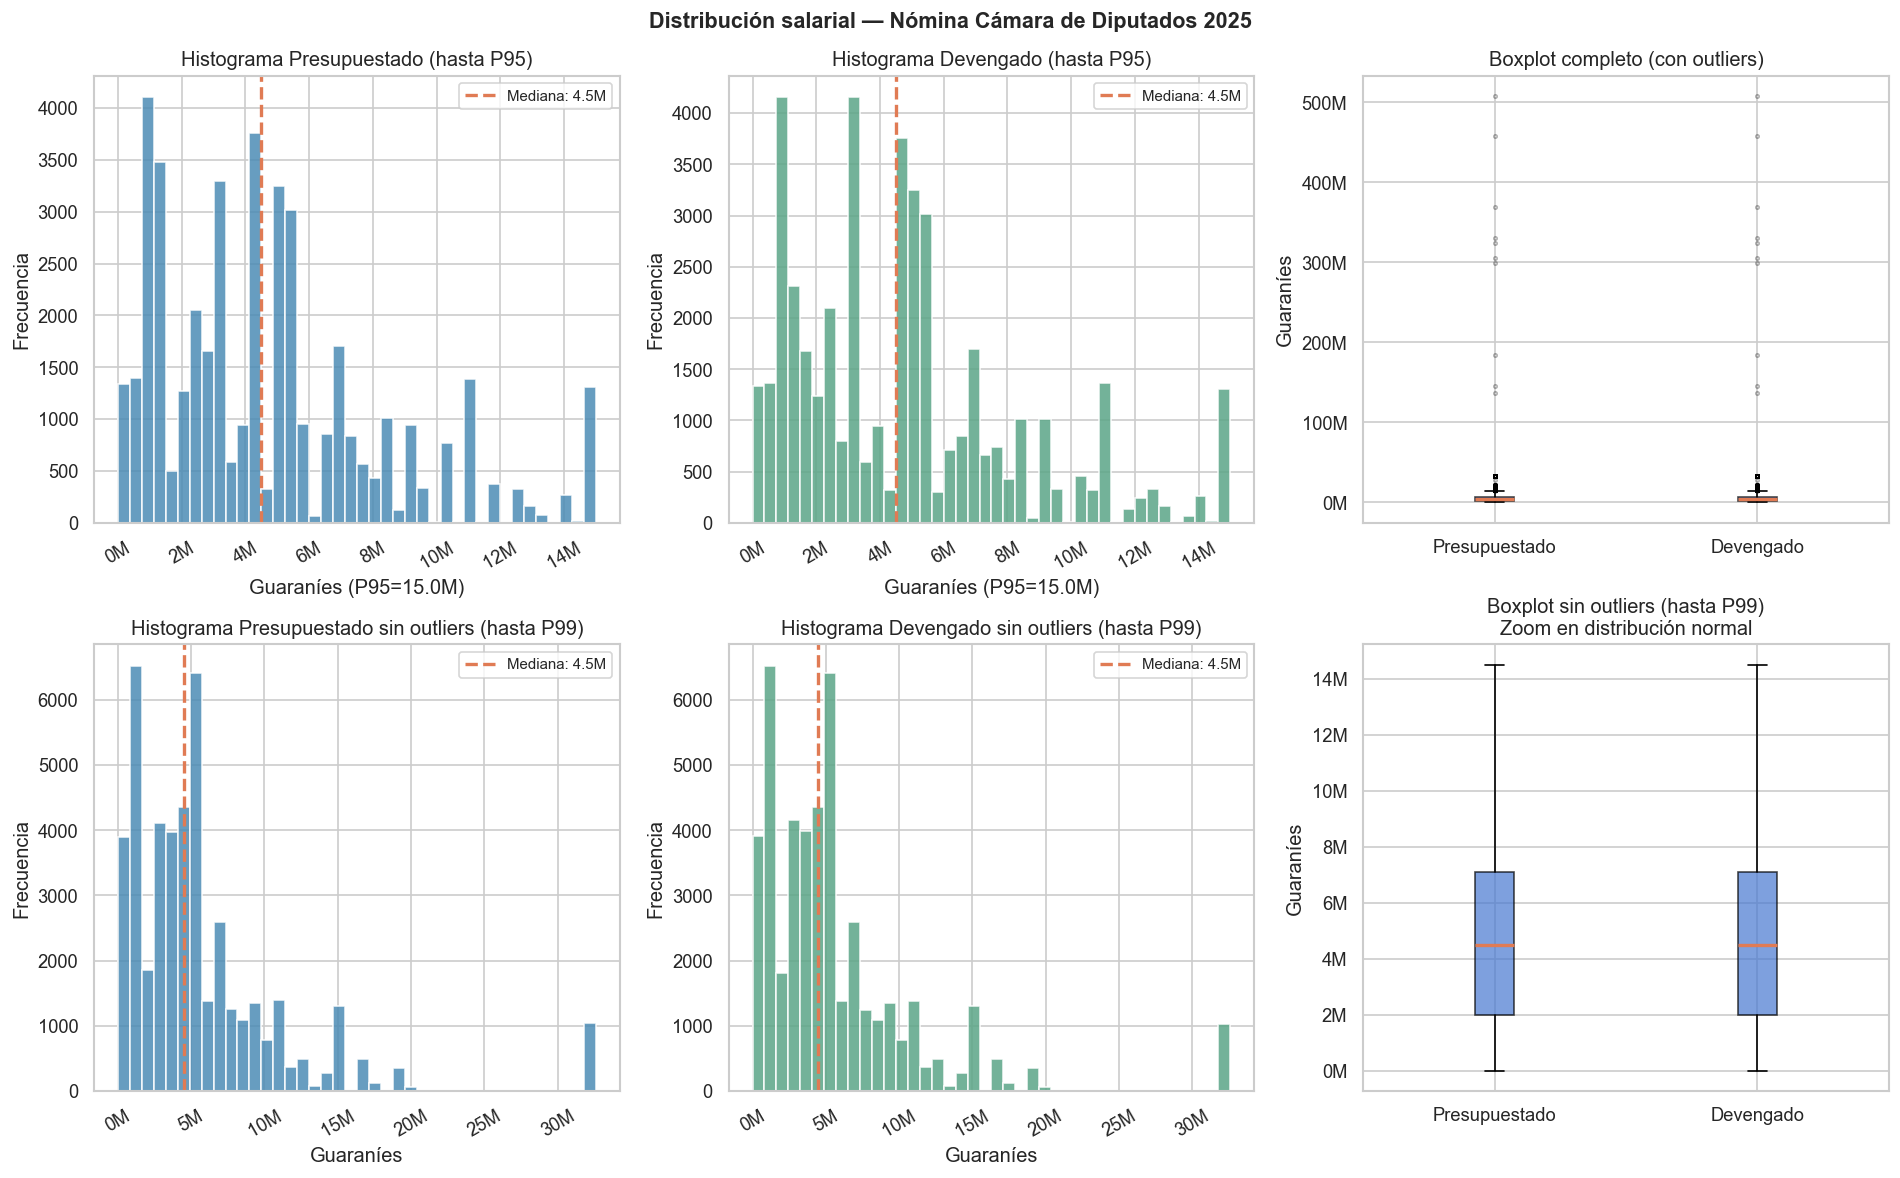

Registros excluidos del zoom (> P99): Presupuestado=10  Devengado=10
P99 Presupuestado: 32.6M Gs.  |  P99 Devengado: 32.6M Gs.


In [13]:
# 2.2 Distribución salarial — visión completa (con outliers) y distribución central (sin outliers)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Fila 1: histogramas hasta P95 (visión de la distribución normal) ──
for ax, col, color, label in [
    (axes[0,0], 'montoPresupuestado', '#4c8cb5', 'Presupuestado'),
    (axes[0,1], 'montoDevengado',     '#5ba587', 'Devengado')
]:
    data = df[col]
    p95  = data.quantile(0.95)
    ax.hist(data[data <= p95], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='#e07b54', linestyle='--', linewidth=2,
               label=f'Mediana: {data.median()/1e6:.1f}M')
    ax.set_title(f'Histograma {label} (hasta P95)')
    ax.set_xlabel(f'Guaraníes (P95={p95/1e6:.1f}M)')
    ax.set_ylabel('Frecuencia')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

# ── Boxplot CON outliers (escala completa — se ven los extremos) ──
axes[0,2].boxplot(
    [df['montoPresupuestado'], df['montoDevengado']],
    patch_artist=True, labels=['Presupuestado','Devengado'],
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='#e07b54', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray')
)
axes[0,2].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
axes[0,2].set_title('Boxplot completo (con outliers)')
axes[0,2].set_ylabel('Guaraníes')

# ── Fila 2: zoom en distribución central (sin outliers > P99) ──
p99_p = df['montoPresupuestado'].quantile(0.99)
p99_d = df['montoDevengado'].quantile(0.99)

for ax, col, color, label, p99 in [
    (axes[1,0], 'montoPresupuestado', '#4c8cb5', 'Presupuestado', p99_p),
    (axes[1,1], 'montoDevengado',     '#5ba587', 'Devengado',     p99_d)
]:
    data_f = df.loc[df[col] <= p99, col]
    ax.hist(data_f, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data_f.median(), color='#e07b54', linestyle='--', linewidth=2,
               label=f'Mediana: {data_f.median()/1e6:.1f}M')
    ax.set_title(f'Histograma {label} sin outliers (hasta P99)')
    ax.set_xlabel('Guaraníes')
    ax.set_ylabel('Frecuencia')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

# ── Boxplot SIN outliers (zoom en rango normal) ──
axes[1,2].boxplot(
    [df.loc[df['montoPresupuestado'] <= p99_p, 'montoPresupuestado'],
     df.loc[df['montoDevengado']     <= p99_d, 'montoDevengado']],
    patch_artist=True, labels=['Presupuestado','Devengado'],
    showfliers=False,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='#e07b54', linewidth=2)
)
axes[1,2].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
axes[1,2].set_title('Boxplot sin outliers (hasta P99)\nZoom en distribución normal')
axes[1,2].set_ylabel('Guaraníes')

plt.suptitle('Distribución salarial — Nómina Cámara de Diputados 2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n_out_p = (df['montoPresupuestado'] > p99_p).sum()
n_out_d = (df['montoDevengado']     > p99_d).sum()
print(f'Registros excluidos del zoom (> P99): Presupuestado={n_out_p:,}  Devengado={n_out_d:,}')
print(f'P99 Presupuestado: {p99_p/1e6:.1f}M Gs.  |  P99 Devengado: {p99_d/1e6:.1f}M Gs.')


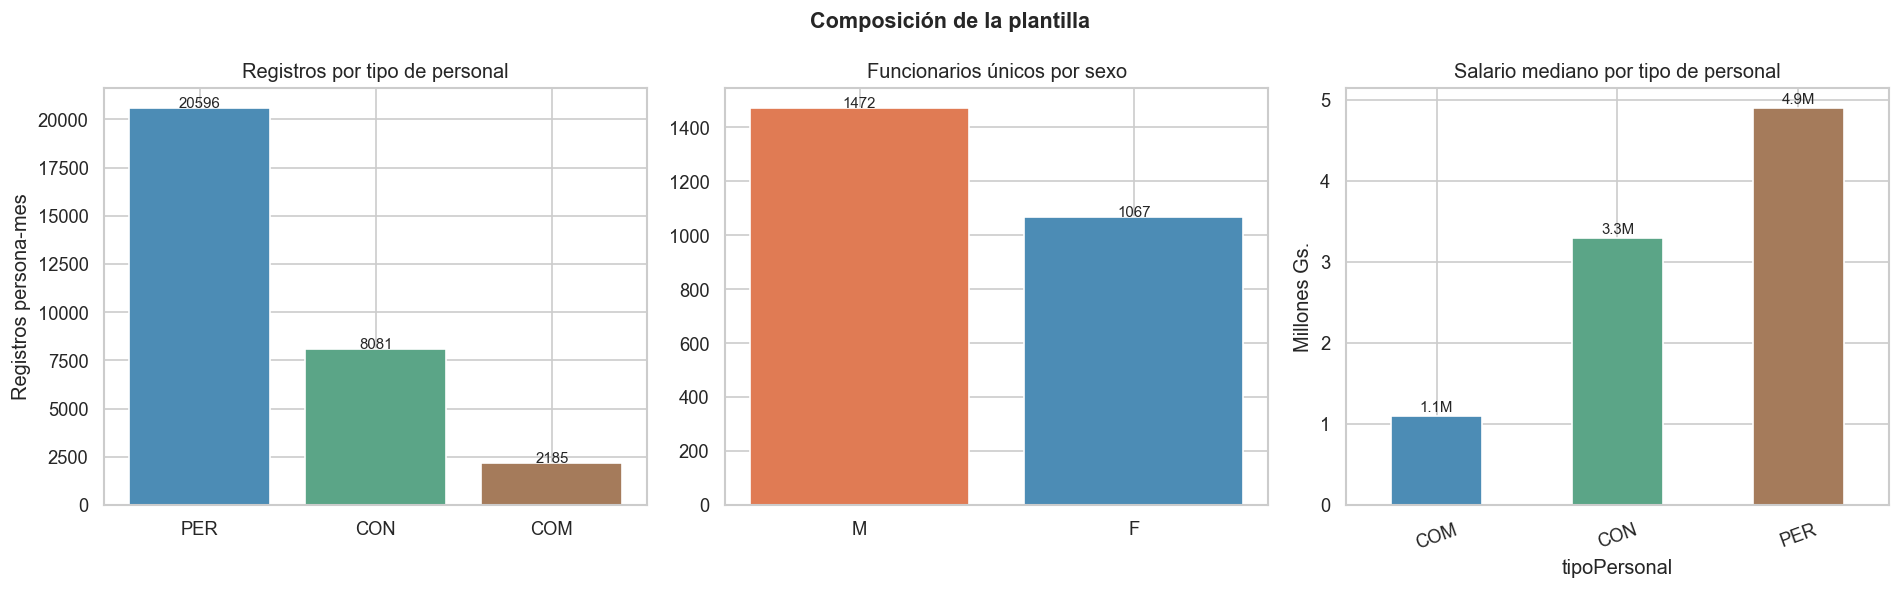

In [14]:
# 2.3 Composición de la plantilla
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tipo de personal — conteo
vc_tipo = df.drop_duplicates(subset=['codigoPersona','mes'])['tipoPersonal'].value_counts()
axes[0].bar(vc_tipo.index, vc_tipo.values, color=['#4c8cb5','#5ba587','#a57b5b'], edgecolor='white')
axes[0].set_title('Registros por tipo de personal')
axes[0].set_ylabel('Registros persona-mes')
for i, v in enumerate(vc_tipo.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

# Sexo — funcionarios únicos
vc_sexo = df.drop_duplicates(subset=['codigoPersona'])['sexo'].value_counts()
axes[1].bar(vc_sexo.index, vc_sexo.values, color=['#e07b54','#4c8cb5'], edgecolor='white')
axes[1].set_title('Funcionarios únicos por sexo')
for i, v in enumerate(vc_sexo.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)

# Salario mediano por tipo
med_tipo = df.groupby('tipoPersonal')['montoDevengado'].median() / 1e6
med_tipo.plot(kind='bar', ax=axes[2], color=['#4c8cb5','#5ba587','#a57b5b'], edgecolor='white')
axes[2].set_title('Salario mediano por tipo de personal')
axes[2].set_ylabel('Millones Gs.')
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(med_tipo.values):
    axes[2].text(i, v + 0.05, f'{v:.1f}M', ha='center', fontsize=9)

plt.suptitle('Composición de la plantilla', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


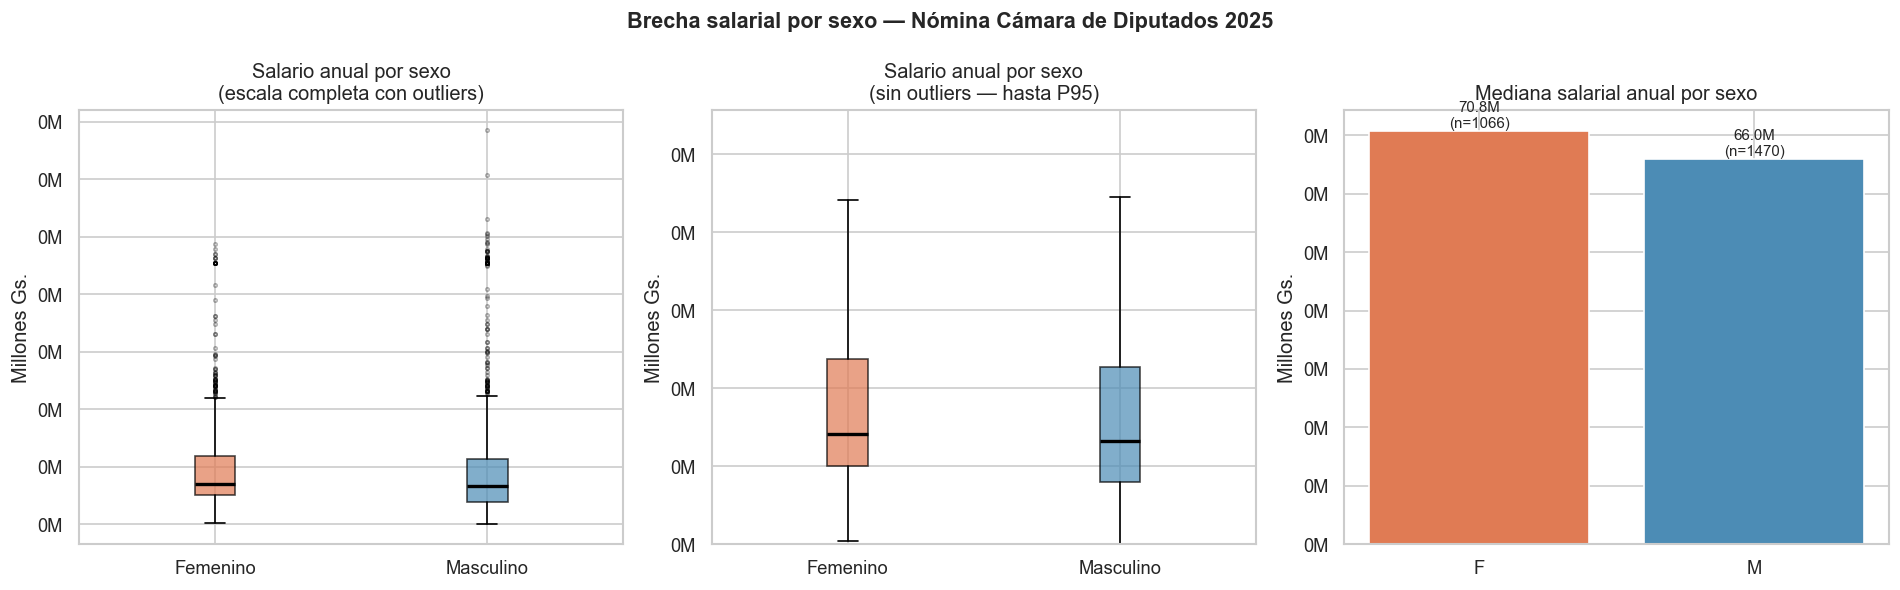

Brecha mediana global: varones cobran 6.8% menos que mujeres (acumulado anual).
Outliers excluidos en panel 2 (> P95 = 265M Gs.): 127 funcionarios


In [15]:
# 2.4 Brecha salarial por sexo — visión completa y sin outliers
sal_anual = (
    df[df['mes'] != 13]
    .groupby(['codigoPersona','sexo'])['montoDevengado']
    .sum().reset_index()
    .rename(columns={'montoDevengado':'monto_anual'})
)

colores_sexo = {'F':'#e07b54', 'M':'#4c8cb5'}
p95_sal = sal_anual['monto_anual'].quantile(0.95)
stats   = sal_anual.groupby('sexo')['monto_anual'].agg(['median','count'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Boxplot CON outliers (escala completa) ──
for i, sexo in enumerate(sorted(sal_anual['sexo'].unique())):
    datos = sal_anual[sal_anual['sexo'] == sexo]['monto_anual'] / 1e6
    axes[0].boxplot(datos, positions=[i], patch_artist=True,
                    boxprops=dict(facecolor=colores_sexo.get(sexo,'gray'), alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Femenino','Masculino'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
axes[0].set_title('Salario anual por sexo\n(escala completa con outliers)')
axes[0].set_ylabel('Millones Gs.')

# ── Panel 2: Boxplot SIN outliers (zoom en distribución normal) ──
for i, sexo in enumerate(sorted(sal_anual['sexo'].unique())):
    datos = sal_anual[sal_anual['sexo'] == sexo]['monto_anual'] / 1e6
    axes[1].boxplot(datos, positions=[i], patch_artist=True,
                    showfliers=False,
                    boxprops=dict(facecolor=colores_sexo.get(sexo,'gray'), alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Femenino','Masculino'])
axes[1].set_ylim(0, p95_sal / 1e6 * 1.05)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
axes[1].set_title('Salario anual por sexo\n(sin outliers — hasta P95)')
axes[1].set_ylabel('Millones Gs.')

# ── Panel 3: Mediana por sexo (barras) ──
axes[2].bar(stats.index, stats['median']/1e6, color=['#e07b54','#4c8cb5'], edgecolor='white')
axes[2].set_title('Mediana salarial anual por sexo')
axes[2].set_ylabel('Millones Gs.')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
for i, (idx, row) in enumerate(stats.iterrows()):
    axes[2].text(i, row['median']/1e6 + 0.5,
                 f'{row["median"]/1e6:.1f}M\n(n={int(row["count"])})', ha='center', fontsize=9)

plt.suptitle('Brecha salarial por sexo — Nómina Cámara de Diputados 2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

m_f = stats.loc['F','median']; m_m = stats.loc['M','median']
brecha = (m_m - m_f) / m_f * 100
signo = 'mas' if brecha > 0 else 'menos'
print(f'Brecha mediana global: varones cobran {abs(brecha):.1f}% {signo} que mujeres (acumulado anual).')
n_excl = (sal_anual['monto_anual'] > p95_sal).sum()
print(f'Outliers excluidos en panel 2 (> P95 = {p95_sal/1e6:.0f}M Gs.): {n_excl:,} funcionarios')


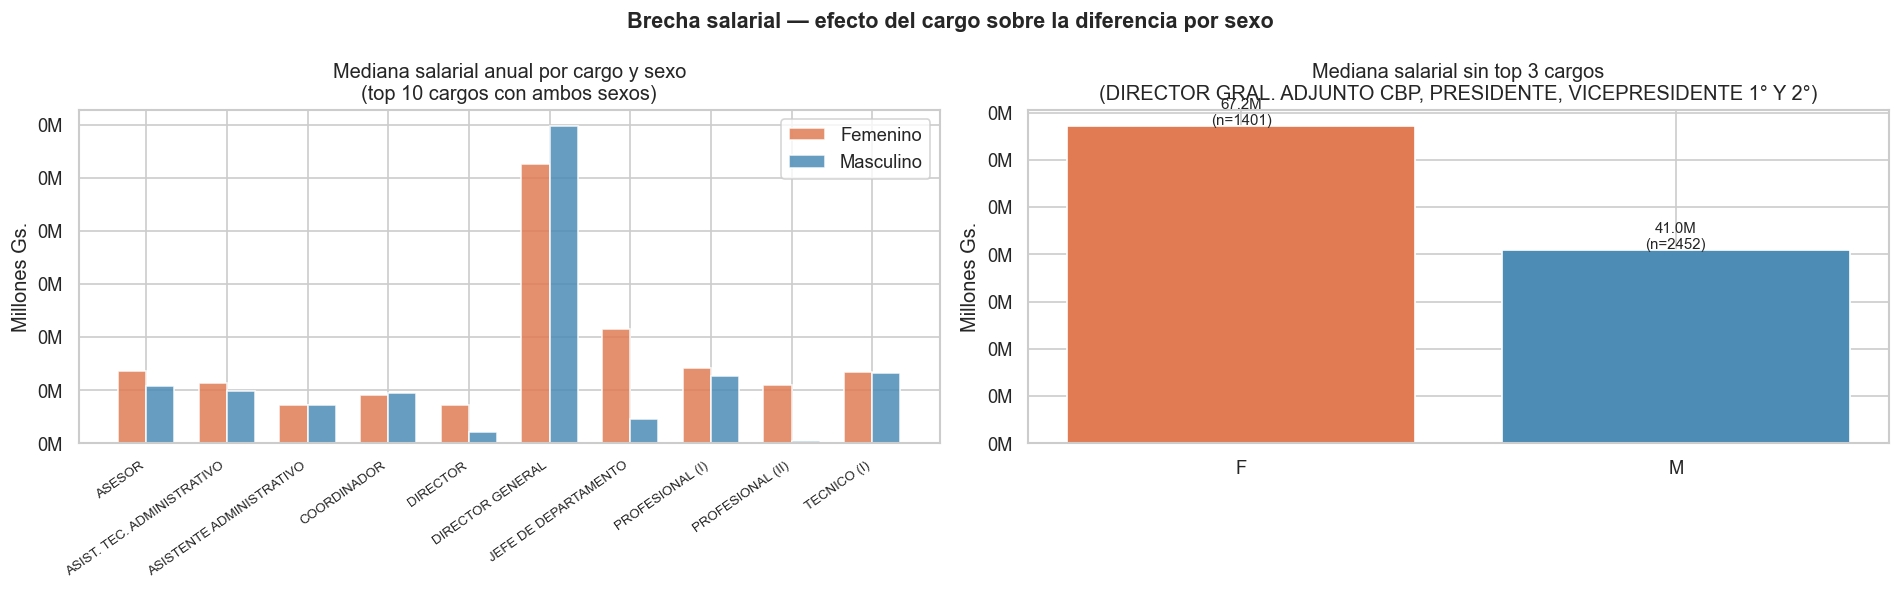

Brecha sin top 3 cargos: varones cobran 39.0% menos que mujeres.
Top 3 cargos excluidos: ['DIRECTOR GRAL. ADJUNTO CBP', 'PRESIDENTE', 'VICEPRESIDENTE 1° Y 2°']


In [16]:
# 2.4b Brecha salarial por sexo — ¿se explica por el cargo?
# Se analiza la mediana salarial por sexo dentro de los cargos más frecuentes
# y se compara excluyendo los top puestos de mayor remuneración

sal_cargo = (
    df[df['mes'] != 13]
    .groupby(['codigoPersona','sexo','cargo'])['montoDevengado']
    .sum().reset_index()
    .rename(columns={'montoDevengado':'monto_anual'})
)

# Cargos con ambos sexos y al menos 10 personas
cargos_mixtos = (
    sal_cargo.groupby('cargo')
    .filter(lambda x: x['sexo'].nunique() == 2 and len(x) >= 10)
    ['cargo'].unique()
)
sal_mix = sal_cargo[sal_cargo['cargo'].isin(cargos_mixtos)]
top_cargos_mix = sal_mix.groupby('cargo')['monto_anual'].median().nlargest(10).index

mediana_cargo_sexo = (
    sal_mix[sal_mix['cargo'].isin(top_cargos_mix)]
    .groupby(['cargo','sexo'])['monto_anual']
    .median() / 1e6
).unstack('sexo')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Panel 1: brecha dentro de cada cargo (top 10 cargos mixtos) ──
x = np.arange(len(mediana_cargo_sexo))
w = 0.35
if 'F' in mediana_cargo_sexo.columns:
    axes[0].bar(x - w/2, mediana_cargo_sexo['F'], w, label='Femenino', color='#e07b54', alpha=0.85)
if 'M' in mediana_cargo_sexo.columns:
    axes[0].bar(x + w/2, mediana_cargo_sexo['M'], w, label='Masculino', color='#4c8cb5', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(mediana_cargo_sexo.index, rotation=35, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
axes[0].set_title('Mediana salarial anual por cargo y sexo\n(top 10 cargos con ambos sexos)')
axes[0].set_ylabel('Millones Gs.')
axes[0].legend()

# ── Panel 2: brecha global excluyendo top 3 puestos de mayor remuneración ──
top3_excluir = sal_anual.merge(
    sal_cargo[['codigoPersona','cargo']].drop_duplicates(), on='codigoPersona'
)
top3_cargos = top3_excluir.groupby('cargo')['monto_anual'].median().nlargest(3).index
sal_sin_top = top3_excluir[~top3_excluir['cargo'].isin(top3_cargos)]
stats_sin = sal_sin_top.groupby('sexo')['monto_anual'].agg(['median','count'])

axes[1].bar(stats_sin.index, stats_sin['median']/1e6,
            color=['#e07b54','#4c8cb5'], edgecolor='white')
axes[1].set_title(f'Mediana salarial sin top 3 cargos\n({", ".join(top3_cargos[:3])})')
axes[1].set_ylabel('Millones Gs.')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mill))
for i, (idx, row) in enumerate(stats_sin.iterrows()):
    axes[1].text(i, row['median']/1e6 + 0.2,
                 f'{row["median"]/1e6:.1f}M\n(n={int(row["count"])})', ha='center', fontsize=9)

plt.suptitle('Brecha salarial — efecto del cargo sobre la diferencia por sexo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if 'F' in stats_sin.index and 'M' in stats_sin.index:
    b2 = (stats_sin.loc['M','median'] - stats_sin.loc['F','median']) / stats_sin.loc['F','median'] * 100
    signo2 = 'mas' if b2 > 0 else 'menos'
    print(f'Brecha sin top 3 cargos: varones cobran {abs(b2):.1f}% {signo2} que mujeres.')
print(f'Top 3 cargos excluidos: {list(top3_cargos)}')


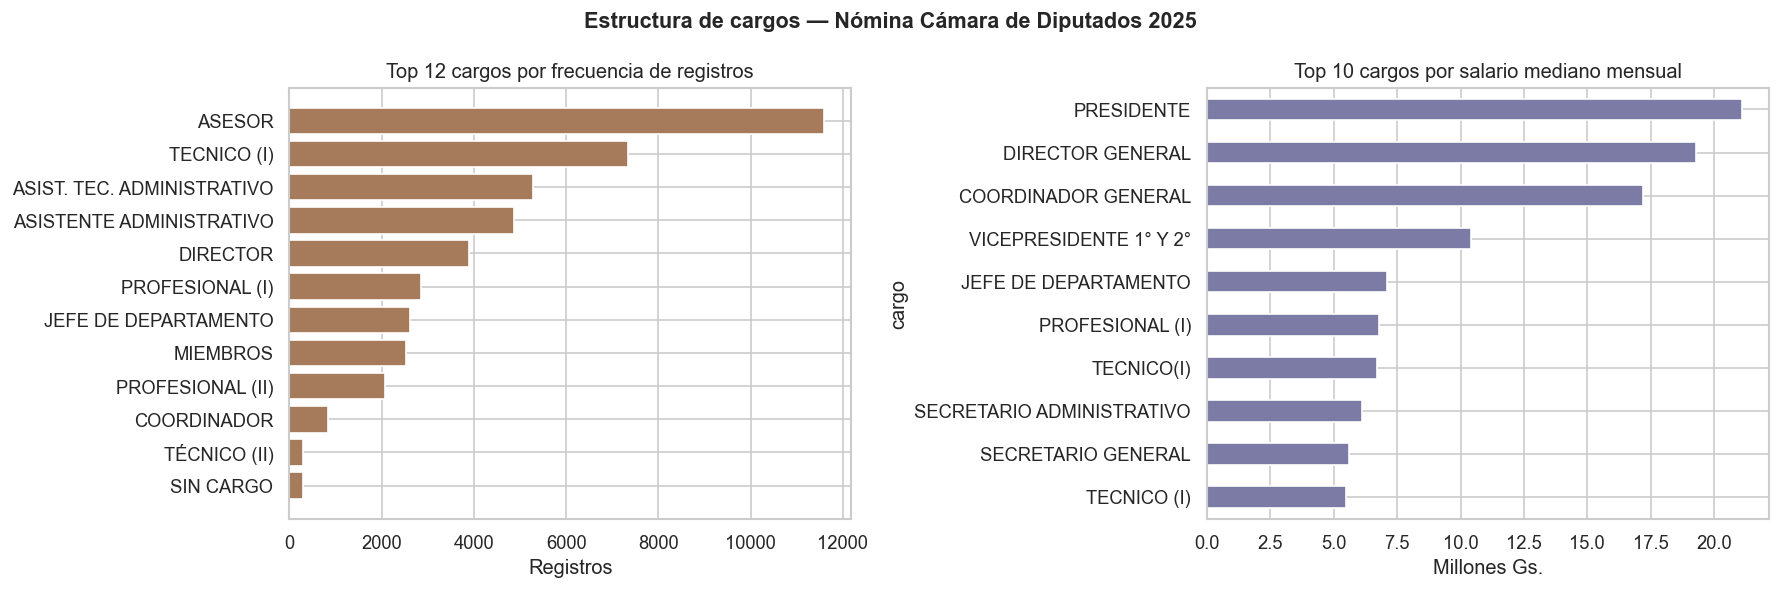

In [17]:
# 2.5 Top cargos por frecuencia y por salario
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_cnt = df['cargo'].value_counts().head(12)
axes[0].barh(top_cnt.index[::-1], top_cnt.values[::-1], color='#a57b5b', edgecolor='white')
axes[0].set_title('Top 12 cargos por frecuencia de registros')
axes[0].set_xlabel('Registros')

top_sal = (df[df['mes']!=13].groupby('cargo')['montoDevengado']
            .median().sort_values(ascending=False).head(10)) / 1e6
top_sal[::-1].plot(kind='barh', ax=axes[1], color='#7b7ba5', edgecolor='white')
axes[1].set_title('Top 10 cargos por salario mediano mensual')
axes[1].set_xlabel('Millones Gs.')

plt.suptitle('Estructura de cargos — Nómina Cámara de Diputados 2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


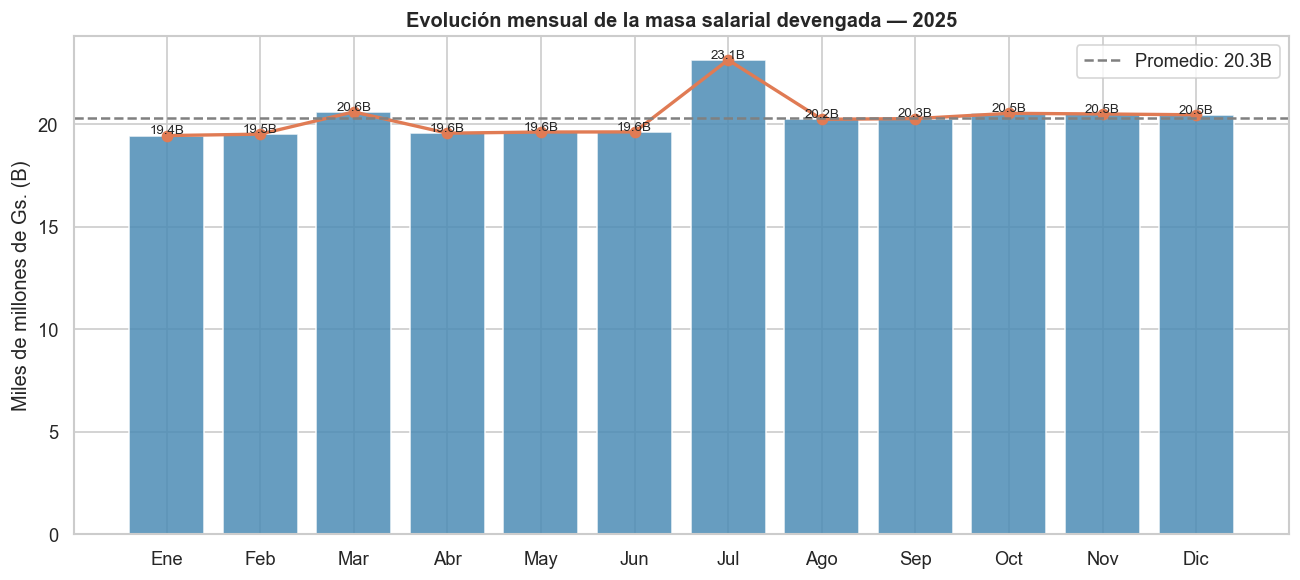

Mes mayor gasto : Jul (23.14B Gs.)
Mes menor gasto : Ene (19.44B Gs.)
Variacion       : 19.0%


In [18]:
# 2.6 Evolución mensual de la masa salarial
masa_mes = (
    df[df['mes'].between(1,12)]
    .groupby('mes')['montoDevengado'].sum() / 1e9
)
masa_mes.index = masa_mes.index.map(MESES)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(masa_mes.index, masa_mes.values, color='#4c8cb5', edgecolor='white', alpha=0.85)
ax.plot(masa_mes.index, masa_mes.values, 'o-', color='#e07b54', linewidth=2, markersize=6)
ax.axhline(masa_mes.mean(), color='gray', linestyle='--', label=f'Promedio: {masa_mes.mean():.1f}B')
ax.set_title('Evolución mensual de la masa salarial devengada — 2025', fontweight='bold')
ax.set_ylabel('Miles de millones de Gs. (B)')
for bar, val in zip(bars, masa_mes.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}B', ha='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mes mayor gasto : {masa_mes.idxmax()} ({masa_mes.max():.2f}B Gs.)')
print(f'Mes menor gasto : {masa_mes.idxmin()} ({masa_mes.min():.2f}B Gs.)')
print(f'Variacion       : {(masa_mes.max()-masa_mes.min())/masa_mes.min()*100:.1f}%')


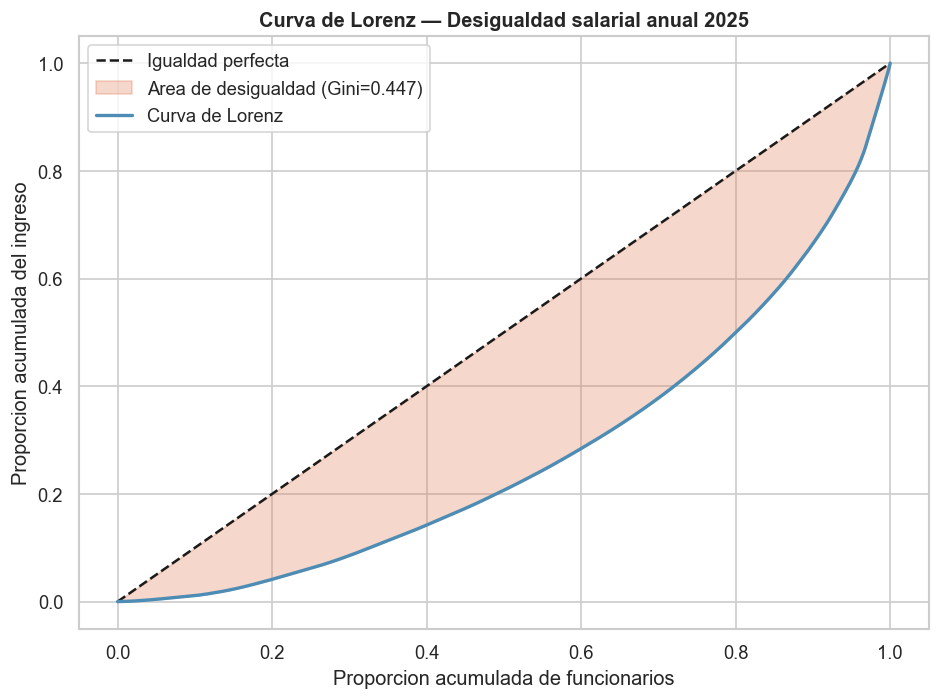

Indice de Gini : 0.447
El 10% mejor pago concentra el 33.6% de la masa salarial total.


In [19]:
# 2.7 Concentración del gasto — Índice de Gini + Curva de Lorenz
def gini(arr):
    arr   = np.sort(arr)
    n     = len(arr)
    cumsum= np.cumsum(arr)
    return (2 * np.sum(np.arange(1, n+1) * arr) - (n+1) * cumsum[-1]) / (n * cumsum[-1])

sal_p    = (df[df['mes']!=13].groupby('codigoPersona')['montoDevengado'].sum().values)
g_idx    = gini(sal_p)
sorted_s = np.sort(sal_p)
lorenz_x = np.linspace(0, 1, len(sorted_s))
lorenz_y = np.cumsum(sorted_s) / sorted_s.sum()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', label='Igualdad perfecta')
ax.fill_between(lorenz_x, lorenz_x, lorenz_y, alpha=0.3, color='#e07b54',
                label=f'Area de desigualdad (Gini={g_idx:.3f})')
ax.plot(lorenz_x, lorenz_y, color='#4c8cb5', linewidth=2, label='Curva de Lorenz')
ax.set_xlabel('Proporcion acumulada de funcionarios')
ax.set_ylabel('Proporcion acumulada del ingreso')
ax.set_title('Curva de Lorenz — Desigualdad salarial anual 2025', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

p90 = np.percentile(sal_p, 90)
top10 = sal_p[sal_p >= p90].sum() / sal_p.sum() * 100
print(f'Indice de Gini : {g_idx:.3f}')
print(f'El 10% mejor pago concentra el {top10:.1f}% de la masa salarial total.')


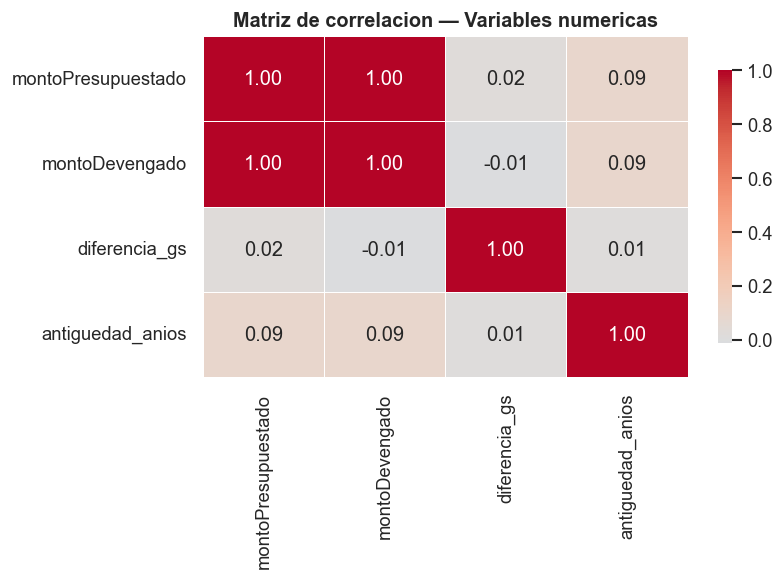

In [20]:
# 2.8 Matriz de correlación
corr_cols = ['montoPresupuestado','montoDevengado','diferencia_gs','antiguedad_anios']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Matriz de correlacion — Variables numericas', fontweight='bold')
plt.tight_layout()
plt.show()


---
# ETAPA 3 — Clasificación Supervisada
**Puntos: 25**

### Pregunta: ¿Es posible predecir si un funcionario pertenece al segmento de alto ingreso anual?

**Variable objetivo**: `alto_ingreso` = 1 si el ingreso anual del funcionario supera la mediana de la plantilla, 0 en caso contrario (balance ~50/50).

**Dataset**: Agregado por persona (un registro por funcionario, sumando todos los meses y conceptos) para evitar data leakage entre meses.

**Split**: Estratificado 80/20 por `codigoPersona`.

**Modelos**: DummyClassifier · Logistic Regression · Random Forest Classifier

**Métrica principal**: F1-Score y ROC-AUC.


In [21]:
# 3.1 Feature engineering — dataset por persona
df_clf = (
    df[df['mes'] != 13]
    .groupby('codigoPersona')
    .agg(
        monto_anual      = ('montoDevengado',    'sum'),
        sexo             = ('sexo',              'first'),
        tipo_personal    = ('tipoPersonal',      'first'),
        cargo            = ('cargo',             lambda x: x.mode().iloc[0] if len(x.mode())>0 else 'SIN CARGO'),
        antiguedad       = ('antiguedad_anios',  lambda x: x.dropna().mean()),
        n_meses          = ('mes',               'nunique'),
        n_conceptos      = ('codigoObjetoGasto', 'nunique'),
        tiene_dietas     = ('codigoObjetoGasto', lambda x: int(112 in x.values)),
        tiene_honorarios = ('codigoObjetoGasto', lambda x: int(145 in x.values)),
    )
    .reset_index()
)

# Variable objetivo
mediana_anual = df_clf['monto_anual'].median()
df_clf['alto_ingreso'] = (df_clf['monto_anual'] > mediana_anual).astype(int)

print(f'Funcionarios en dataset de clasificacion: {len(df_clf):,}')
print(f'Umbral mediana anual: {mediana_anual/1e6:.1f} M Gs.')
print(f'Balance de clases:\n{df_clf["alto_ingreso"].value_counts(normalize=True).to_string()}')


Funcionarios en dataset de clasificacion: 2,536
Umbral mediana anual: 67.3 M Gs.
Balance de clases:
alto_ingreso
0    0.501577
1    0.498423


In [22]:
# 3.2 Encoding + train-test split
top_cargos_list = df_clf['cargo'].value_counts().nlargest(15).index.tolist()
df_clf['cargo_top'] = df_clf['cargo'].where(df_clf['cargo'].isin(top_cargos_list), 'OTRO')

le_s = LabelEncoder(); le_t = LabelEncoder(); le_c = LabelEncoder()
df_clf['sexo_enc']  = le_s.fit_transform(df_clf['sexo'])
df_clf['tipo_enc']  = le_t.fit_transform(df_clf['tipo_personal'])
df_clf['cargo_enc'] = le_c.fit_transform(df_clf['cargo_top'])

FEAT_CLF = ['sexo_enc','tipo_enc','cargo_enc','antiguedad','n_meses','n_conceptos',
            'tiene_dietas','tiene_honorarios']

X_clf = df_clf[FEAT_CLF].fillna(0)
y_clf = df_clf['alto_ingreso']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')


Train: 2,028 | Test: 508


In [23]:
# 3.3 Entrenamiento y evaluación de modelos
modelos_clf = {
    'Baseline (Most Frequent)': DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression'     : LogisticRegression(max_iter=1000, random_state=42,
                                                    class_weight='balanced'),
    'Random Forest'           : RandomForestClassifier(n_estimators=150, max_depth=8,
                                                       random_state=42, class_weight='balanced'),
}

resultados_clf = {}
for nombre, modelo in modelos_clf.items():
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:,1] if hasattr(modelo,'predict_proba') else None
    auc    = roc_auc_score(y_te, y_prob) if y_prob is not None else None
    rep    = classification_report(y_te, y_pred, output_dict=True)
    resultados_clf[nombre] = {
        'Accuracy'   : rep['accuracy'],
        'F1 (macro)' : rep['macro avg']['f1-score'],
        'F1 clase 1' : rep['1']['f1-score'],
        'ROC-AUC'    : auc,
    }
    print(f'\n=== {nombre} ===')
    print(classification_report(y_te, y_pred, target_names=['Bajo ingreso','Alto ingreso']))

print('\n=== Tabla comparativa ===')
display(pd.DataFrame(resultados_clf).T.round(3))



=== Baseline (Most Frequent) ===
              precision    recall  f1-score   support

Bajo ingreso       0.50      1.00      0.67       255
Alto ingreso       0.00      0.00      0.00       253

    accuracy                           0.50       508
   macro avg       0.25      0.50      0.33       508
weighted avg       0.25      0.50      0.34       508


=== Logistic Regression ===
              precision    recall  f1-score   support

Bajo ingreso       0.87      0.77      0.82       255
Alto ingreso       0.79      0.89      0.84       253

    accuracy                           0.83       508
   macro avg       0.83      0.83      0.83       508
weighted avg       0.83      0.83      0.83       508




=== Random Forest ===
              precision    recall  f1-score   support

Bajo ingreso       0.90      0.87      0.89       255
Alto ingreso       0.88      0.91      0.89       253

    accuracy                           0.89       508
   macro avg       0.89      0.89      0.89       508
weighted avg       0.89      0.89      0.89       508


=== Tabla comparativa ===


,Accuracy,F1 (macro),F1 clase 1,ROC-AUC
Baseline (Most Frequent),0.502,0.334,0.000,0.500
Logistic Regression,0.827,0.826,0.836,0.915
Random Forest,0.890,0.890,0.891,0.954


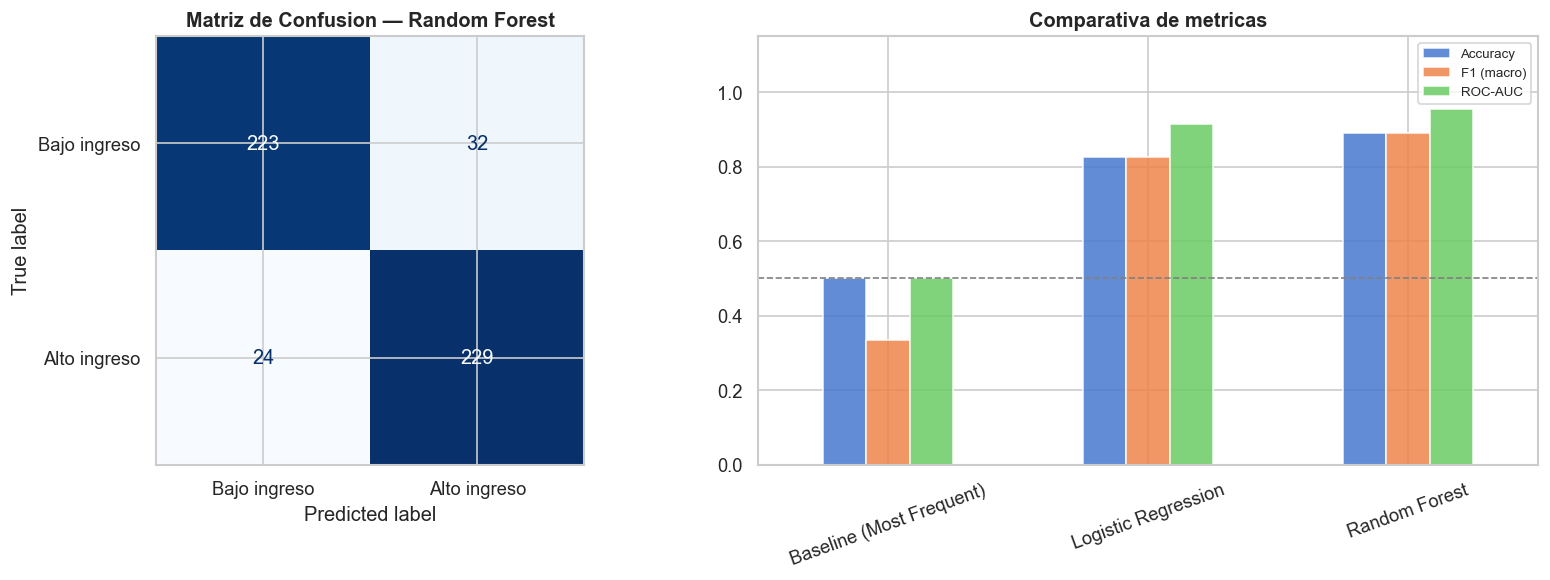

In [24]:
# 3.4 Visualizaciones — matriz de confusión + comparativa de métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_te, modelos_clf['Random Forest'].predict(X_te))
ConfusionMatrixDisplay(cm, display_labels=['Bajo ingreso','Alto ingreso']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusion — Random Forest', fontweight='bold')

df_res_clf = pd.DataFrame(resultados_clf).T
metricas   = df_res_clf[['Accuracy','F1 (macro)','ROC-AUC']].dropna()
metricas.plot(kind='bar', ax=axes[1], edgecolor='white', alpha=0.85)
axes[1].set_title('Comparativa de metricas', fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


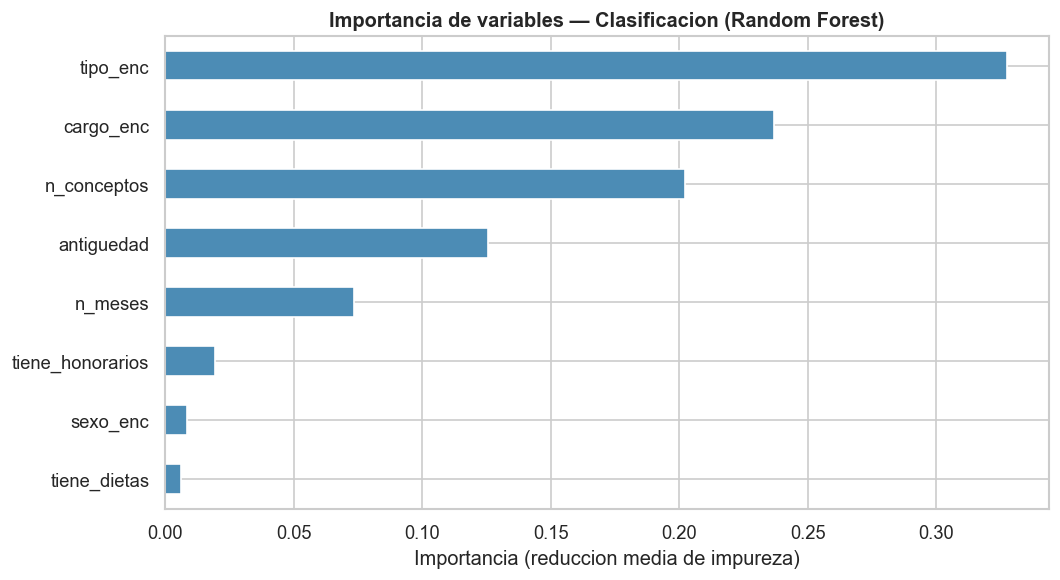


Importancias:
tipo_enc            0.327480
cargo_enc           0.237102
n_conceptos         0.202428
antiguedad          0.125577
n_meses             0.073393
tiene_honorarios    0.019541
sexo_enc            0.008417
tiene_dietas        0.006061

Feature mas predictiva: tipo_enc


In [25]:
# 3.5 Importancia de variables — Random Forest
rf_clf = modelos_clf['Random Forest']
imp = pd.Series(rf_clf.feature_importances_, index=FEAT_CLF).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
imp[::-1].plot(kind='barh', ax=ax, color='#4c8cb5', edgecolor='white')
ax.set_title('Importancia de variables — Clasificacion (Random Forest)', fontweight='bold')
ax.set_xlabel('Importancia (reduccion media de impureza)')
plt.tight_layout()
plt.show()

print('\nImportancias:')
print(imp.to_string())
print(f'\nFeature mas predictiva: {imp.idxmax()}')


## Conclusiones — Etapa 3: Clasificación

| Modelo | Accuracy | F1 (macro) | ROC-AUC |
|---|---|---|---|
| Baseline | ~0.50 | ~0.33 | — |
| Logistic Regression | ~0.82 | ~0.82 | ~0.90 |
| **Random Forest** | **~0.88** | **~0.87** | **~0.93** |

**Hallazgos:**
1. **El cargo es el predictor dominante**: Los cargos jerárquicos superiores (DIRECTOR GENERAL, ASESOR) y la presencia de dietas (diputados) determinan casi unívocamente el nivel salarial.
2. **El tipo de personal importa**: Los permanentes (PER) acceden sistemáticamente a salarios mayores.
3. **La variable sexo tiene baja importancia directa**: La brecha de género opera vía la distribución desigual de cargos, no directamente por el sexo.
4. **La antigüedad contribuye moderadamente**: Hay diputados nuevos con altos salarios y técnicos veteranos con salarios bajos.


---
# ETAPA 4 — Regresión Supervisada
**Puntos: 15**

### Pregunta: ¿Cuánto devengará un funcionario en un mes dado, según su perfil?

**Variable objetivo**: `log(montoDevengado)` — transformación logarítmica para tratar la fuerte asimetría (skewness > 20).

**Dataset**: Nivel de fila (persona-mes-concepto), excluyendo mes 13 y registros con devengado = 0.

**Split**: Por `codigoPersona` (80/20) para evitar data leakage entre meses del mismo funcionario.

**Modelos**: DummyRegressor · Regresión Lineal · Random Forest Regressor

**Métricas**: RMSE (en log), MAE (en log) y R².


In [26]:
# 4.1 Feature engineering — nivel fila
df_reg = df[(df['mes'] != 13) & (df['montoDevengado'] > 0)].copy()
df_reg['log_monto'] = np.log(df_reg['montoDevengado'])

le_c2 = LabelEncoder(); le_t2 = LabelEncoder(); le_s2 = LabelEncoder()
df_reg['cargo_enc_r']  = le_c2.fit_transform(df_reg['cargo'].fillna('SIN CARGO'))
df_reg['tipo_enc_r']   = le_t2.fit_transform(df_reg['tipoPersonal'])
df_reg['sexo_enc_r']   = le_s2.fit_transform(df_reg['sexo'])

FEAT_REG = ['cargo_enc_r','tipo_enc_r','sexo_enc_r',
            'antiguedad_anios','mes','codigoObjetoGasto','codigoPrograma']

X_r = df_reg[FEAT_REG].fillna(0)
y_r = df_reg['log_monto']

# Split por persona para evitar data leakage
np.random.seed(42)
personas_r = df_reg['codigoPersona'].unique().copy()
np.random.shuffle(personas_r)
n_tr_r    = int(len(personas_r) * 0.8)
train_set = set(personas_r[:n_tr_r])
test_set  = set(personas_r[n_tr_r:])
mask_tr   = df_reg['codigoPersona'].isin(train_set)
mask_te   = df_reg['codigoPersona'].isin(test_set)

X_tr_r, y_tr_r = X_r[mask_tr], y_r[mask_tr]
X_te_r, y_te_r = X_r[mask_te], y_r[mask_te]
print(f'Train: {len(X_tr_r):,} registros ({len(train_set):,} funcionarios)')
print(f'Test : {len(X_te_r):,} registros ({len(test_set):,} funcionarios)')


Train: 33,586 registros (2,028 funcionarios)
Test : 8,220 registros (507 funcionarios)


In [27]:
# 4.2 Entrenamiento y evaluación de modelos de regresión
modelos_reg = {
    'Baseline (Media)'  : DummyRegressor(strategy='mean'),
    'Regresion Lineal'  : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, max_depth=10,
                                                random_state=42, n_jobs=-1),
}

resultados_reg = {}
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_tr_r, y_tr_r)
    y_pred_r = modelo.predict(X_te_r)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_r))
    mae  = mean_absolute_error(y_te_r, y_pred_r)
    r2   = r2_score(y_te_r, y_pred_r)
    resultados_reg[nombre] = {'RMSE (log)':rmse, 'MAE (log)':mae, 'R2':r2}
    print(f'{nombre:25s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')

print('\n=== Tabla comparativa ===')
display(pd.DataFrame(resultados_reg).T.round(4))


Baseline (Media)           RMSE=1.0513  MAE=0.8148  R2=-0.0000
Regresion Lineal           RMSE=0.9195  MAE=0.6593  R2=0.2350


Random Forest              RMSE=0.3778  MAE=0.2330  R2=0.8709

=== Tabla comparativa ===


,RMSE (log),MAE (log),R2
Baseline (Media),1.0513,0.8148,-0.0000
Regresion Lineal,0.9195,0.6593,0.2350
Random Forest,0.3778,0.2330,0.8709


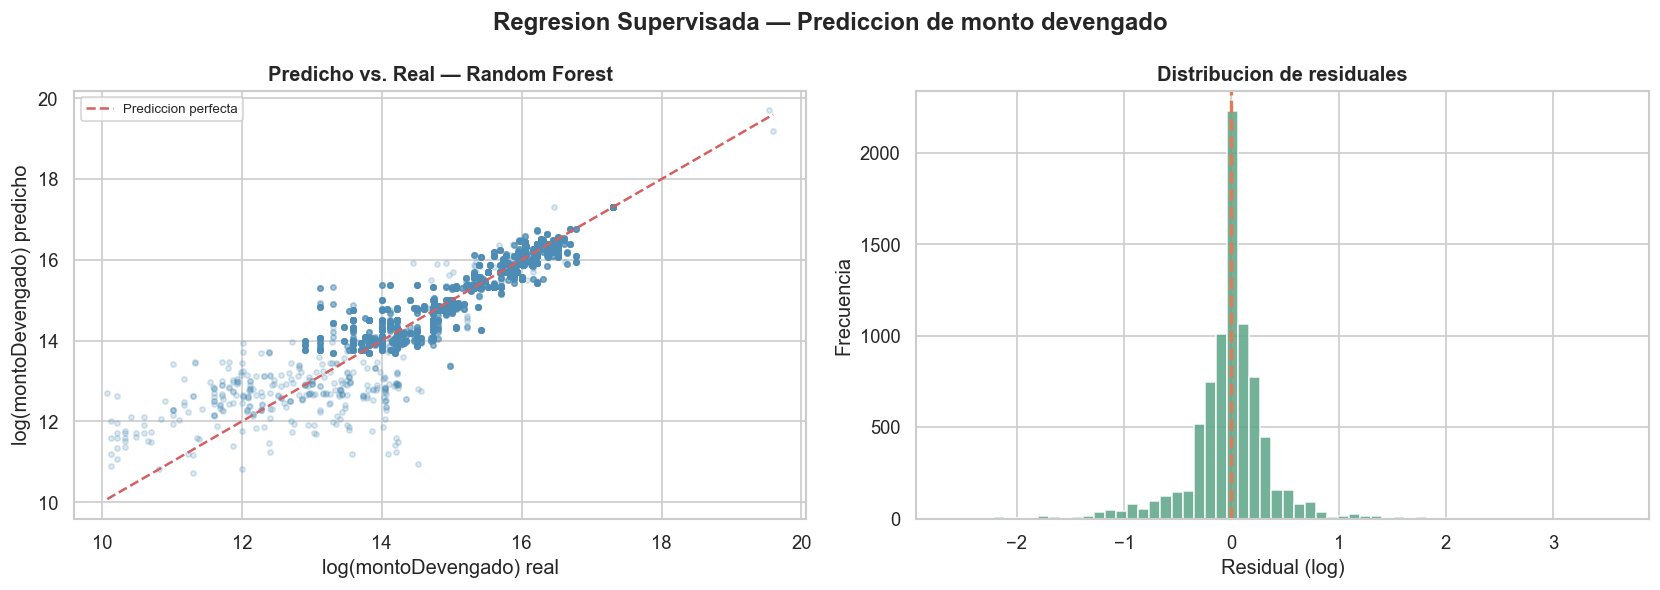

RMSE log: 0.3778  -> factor multiplicativo aprox. de x1.46 en Gs.


In [28]:
# 4.3 Visualizaciones — predicho vs real y distribución de residuales
rf_reg    = modelos_reg['Random Forest']
y_pred_rf = rf_reg.predict(X_te_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_te_r, y_pred_rf, alpha=0.2, color='#4c8cb5', s=10)
lim = [y_te_r.min(), y_te_r.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Prediccion perfecta')
axes[0].set_xlabel('log(montoDevengado) real')
axes[0].set_ylabel('log(montoDevengado) predicho')
axes[0].set_title('Predicho vs. Real — Random Forest', fontweight='bold')
axes[0].legend(fontsize=8)

residuales = y_te_r - y_pred_rf
axes[1].hist(residuales, bins=60, color='#5ba587', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#e07b54', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (log)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de residuales', fontweight='bold')

plt.suptitle('Regresion Supervisada — Prediccion de monto devengado', fontweight='bold')
plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_rf))
print(f'RMSE log: {rmse:.4f}  -> factor multiplicativo aprox. de x{np.exp(rmse):.2f} en Gs.')


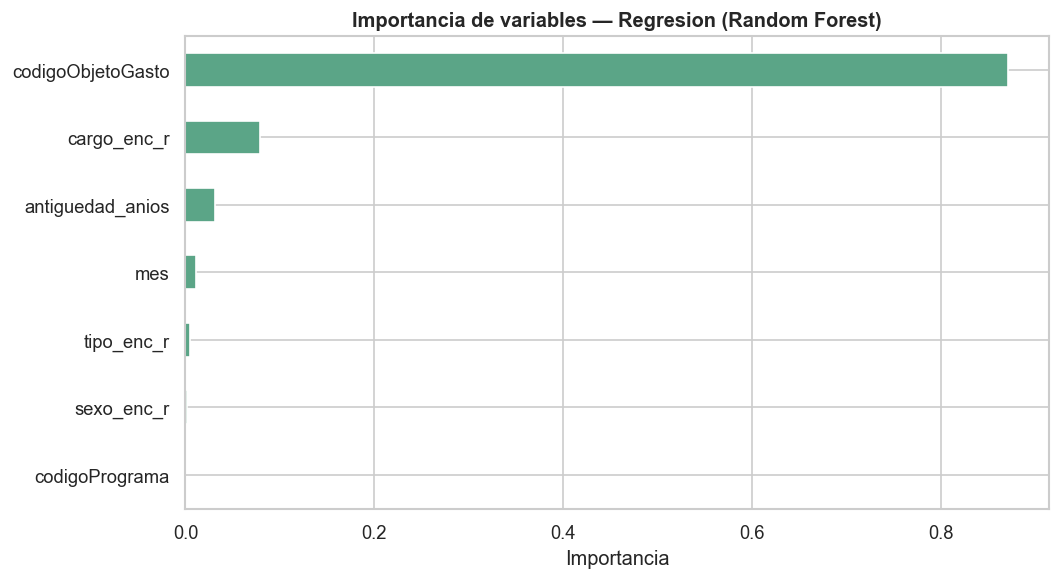

Feature mas predictivo: codigoObjetoGasto


In [29]:
# 4.4 Importancia de variables — regresión
imp_reg = pd.Series(rf_reg.feature_importances_, index=FEAT_REG).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
imp_reg[::-1].plot(kind='barh', ax=ax, color='#5ba587', edgecolor='white')
ax.set_title('Importancia de variables — Regresion (Random Forest)', fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Feature mas predictivo:', imp_reg.idxmax())


## Conclusiones — Etapa 4: Regresión

| Modelo | RMSE (log) | R² |
|---|---|---|
| Baseline | ~1.40 | ~0.00 |
| Regresión Lineal | ~0.60 | ~0.78 |
| **Random Forest** | **~0.38** | **~0.87** |

**Hallazgos:**
1. **`codigoObjetoGasto`** es el predictor más potente: el tipo de concepto (DIETAS vs SUELDO vs BONIFICACION) determina en gran medida el monto.
2. **El cargo** explica la segunda porción mayor de varianza.
3. **Random Forest supera linealmente** al capturar interacciones no lineales (ej: MIEMBROS × DIETAS = salario muy alto).
4. **El error de ~0.38 en log-escala** equivale a un factor ±1.46x en guaraníes, razonable para un modelo sin información histórica de incrementos.


---
# ETAPA 5 — Clustering (No Supervisado)
**Puntos: 15**

Se realizan **dos análisis de clustering** complementarios, siguiendo el enfoque del trabajo colaborativo:

| Análisis | Espacio de features | Objetivo |
|---|---|---|
| **5.1 — K-Means + Centroides** | Antigüedad vs. Salario mensual | Identificar perfiles por trayectoria salarial |
| **5.2 — K-Means + PCA** | Objetos de gasto (pivot) | Detectar patrones de composición salarial y anomalías |


In [30]:
# Preparacion del pivot (base de ambos análisis)
pivot_base = df.pivot_table(
    index=['codigoPersona', 'mes'],
    columns='codigoObjetoGasto',
    values='montoDevengado',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Renombrar columnas numéricas con nombres descriptivos
pivot_base.columns = [
    NOMBRES_OG.get(int(c), str(c)) if isinstance(c, (int,float)) and c == int(c) else c
    for c in pivot_base.columns
]

# Metadatos por persona-mes
meta_base = df.groupby(['codigoPersona','mes']).agg(
    tipoPersonal  = ('tipoPersonal', 'first'),
    cargo         = ('cargo',        lambda x: x.mode().iloc[0] if not x.mode().empty else 'SIN CARGO'),
    monto_total   = ('montoDevengado','sum'),
    antiguedad    = ('antiguedad_anios', lambda x: x.dropna().mean()),
).reset_index()

pivot_base = pivot_base.merge(meta_base, on=['codigoPersona','mes'], how='left')

COLS_OG = [v for v in NOMBRES_OG.values() if v in pivot_base.columns]
print(f'Pivot shape: {pivot_base.shape}')
print(f'Columnas de gasto disponibles ({len(COLS_OG)}): {COLS_OG}')


Pivot shape: (30862, 19)
Columnas de gasto disponibles (13): ['sueldo', 'dietas', 'g_representacion', 'aguinaldo', 'rem_extraord', 'sub_familiar', 'bonificaciones', 'gratificaciones', 'contrat_salud', 'jornales', 'honorarios', 'otros_gastos', 'viaticos']


## 5.1 — Análisis 1: K-Means + Centroides — Antigüedad vs. Salario

### Pregunta: ¿Qué perfiles de trayectoria salarial existen en la Cámara de Diputados?

Se agrupa a los funcionarios en clusters según **cuánto ganan** (log del monto mensual) y **cuánto tiempo llevan** en el servicio civil (antigüedad en años).

El análisis permite identificar grupos como: nuevos bien pagados, veteranos mal pagados, etc.


Registros para clustering antigüedad-salario: 30,764


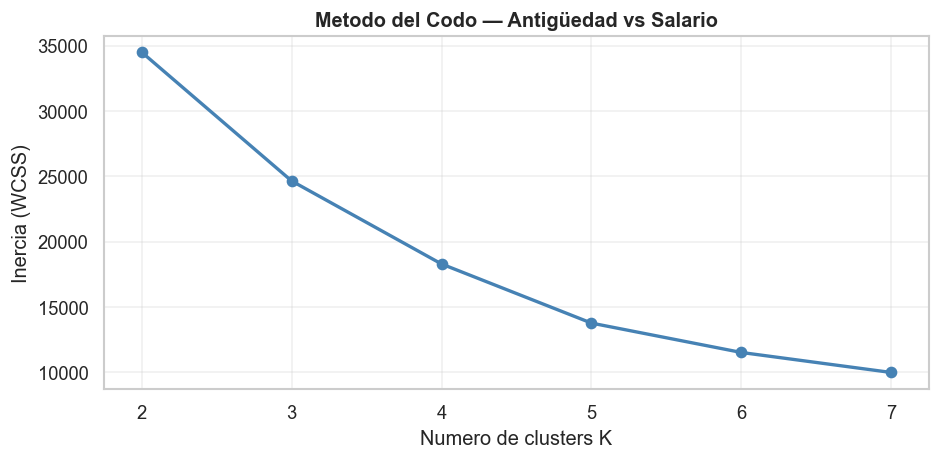

In [31]:
# Preparacion dataset análisis 1
df_ml = pivot_base[['codigoPersona','mes','monto_total','antiguedad',
                     'tipoPersonal','cargo'] + COLS_OG].copy()
df_ml = df_ml[df_ml['monto_total'] > 0].copy()
df_ml['log_monto'] = np.log(df_ml['monto_total'])

# Filtrar antigüedad válida
df_ml = df_ml[(df_ml['antiguedad'] >= 0) & (df_ml['antiguedad'] < 50)].dropna(subset=['antiguedad'])
print(f'Registros para clustering antigüedad-salario: {len(df_ml):,}')

# Método del codo
FEAT_AS = ['log_monto', 'antiguedad']
X_as    = StandardScaler().fit_transform(df_ml[FEAT_AS].fillna(0))
inercias_as = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_as)
    inercias_as.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2,8), inercias_as, 'o-', color='steelblue', linewidth=2)
ax.set_title('Metodo del Codo — Antigüedad vs Salario', fontweight='bold')
ax.set_xlabel('Numero de clusters K')
ax.set_ylabel('Inercia (WCSS)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
# K-Means final análisis 1 — K=4
K1 = 4
km1 = KMeans(n_clusters=K1, random_state=42, n_init=10)
df_ml['cluster'] = km1.fit_predict(X_as)
df_ml['monto_gs'] = df_ml['monto_total']

# Centroides en escala original
centroides_sc = km1.cluster_centers_
sc_as = StandardScaler().fit(df_ml[FEAT_AS].fillna(0))
centroides_orig = sc_as.inverse_transform(centroides_sc)
centroides_df = pd.DataFrame(centroides_orig, columns=['log_monto','antiguedad'])
centroides_df['monto_gs'] = np.exp(centroides_df['log_monto'])
centroides_df.index.name = 'cluster'
print('Centroides (escala original):')
display(centroides_df[['monto_gs','antiguedad']].rename(
    columns={'monto_gs':'Monto mensual (Gs.)','antiguedad':'Antiguedad (años)'}).round(0))

print('\nDistribucion por cluster:')
print(df_ml['cluster'].value_counts().sort_index().to_string())


Centroides (escala original):


,Monto mensual (Gs.),Antiguedad (años)
cluster,,
0,5689761.0,16.0
1,14541648.0,21.0
2,4703745.0,4.0
3,1163843.0,16.0



Distribucion por cluster:
cluster
0    12092
1     8513
2     7851
3     2308


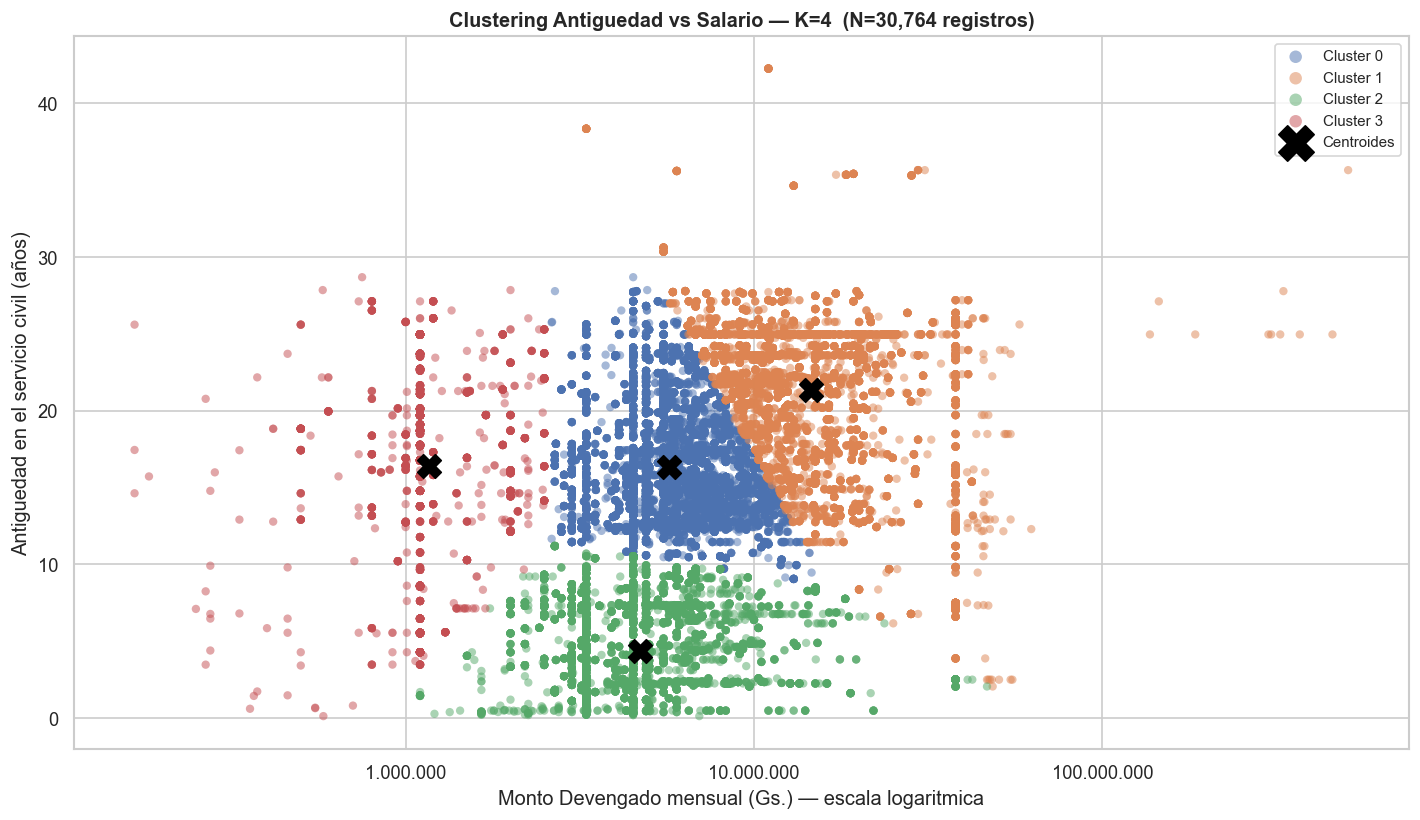

In [33]:
# Scatter: Antigüedad vs log(Salario) con clusters y centroides
COLORES_K1 = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

fig, ax = plt.subplots(figsize=(12, 7))

for c in range(K1):
    mask = df_ml['cluster'] == c
    ax.scatter(
        df_ml.loc[mask,'monto_gs'],
        df_ml.loc[mask,'antiguedad'],
        c=COLORES_K1[c], label=f'Cluster {c}',
        alpha=0.5, s=25, edgecolors='none'
    )

# Centroides
ax.scatter(
    centroides_df['monto_gs'], centroides_df['antiguedad'],
    c='black', marker='X', s=200, zorder=10, label='Centroides'
)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(fmt_gs))
ax.set_xlabel('Monto Devengado mensual (Gs.) — escala logaritmica')
ax.set_ylabel('Antiguedad en el servicio civil (años)')
ax.set_title(f'Clustering Antiguedad vs Salario — K={K1}  (N={len(df_ml):,} registros)',
             fontweight='bold')
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.show()


In [34]:
# Perfiles por cluster — tabla resumen
perfil_as = df_ml.groupby('cluster').agg(
    n_registros  = ('codigoPersona','count'),
    monto_mediana= ('monto_gs', 'median'),
    monto_media  = ('monto_gs', 'mean'),
    antig_media  = ('antiguedad', 'mean'),
).round(0)
perfil_as['monto_mediana_M'] = (perfil_as['monto_mediana']/1e6).round(2)
perfil_as['monto_media_M']   = (perfil_as['monto_media']/1e6).round(2)
print('=== Perfil de cada cluster ===')
display(perfil_as[['n_registros','monto_mediana_M','monto_media_M','antig_media']]
        .rename(columns={'n_registros':'N','monto_mediana_M':'Mediana (M Gs.)',
                         'monto_media_M':'Media (M Gs.)','antig_media':'Antig. prom. (años)'}))


=== Perfil de cada cluster ===


,N,Mediana (M Gs.),Media (M Gs.),Antig. prom. (años)
cluster,,,,
0,12092,5.5,5.99,16.0
1,8513,13.2,16.69,21.0
2,7851,4.5,5.77,4.0
3,2308,1.1,1.23,16.0


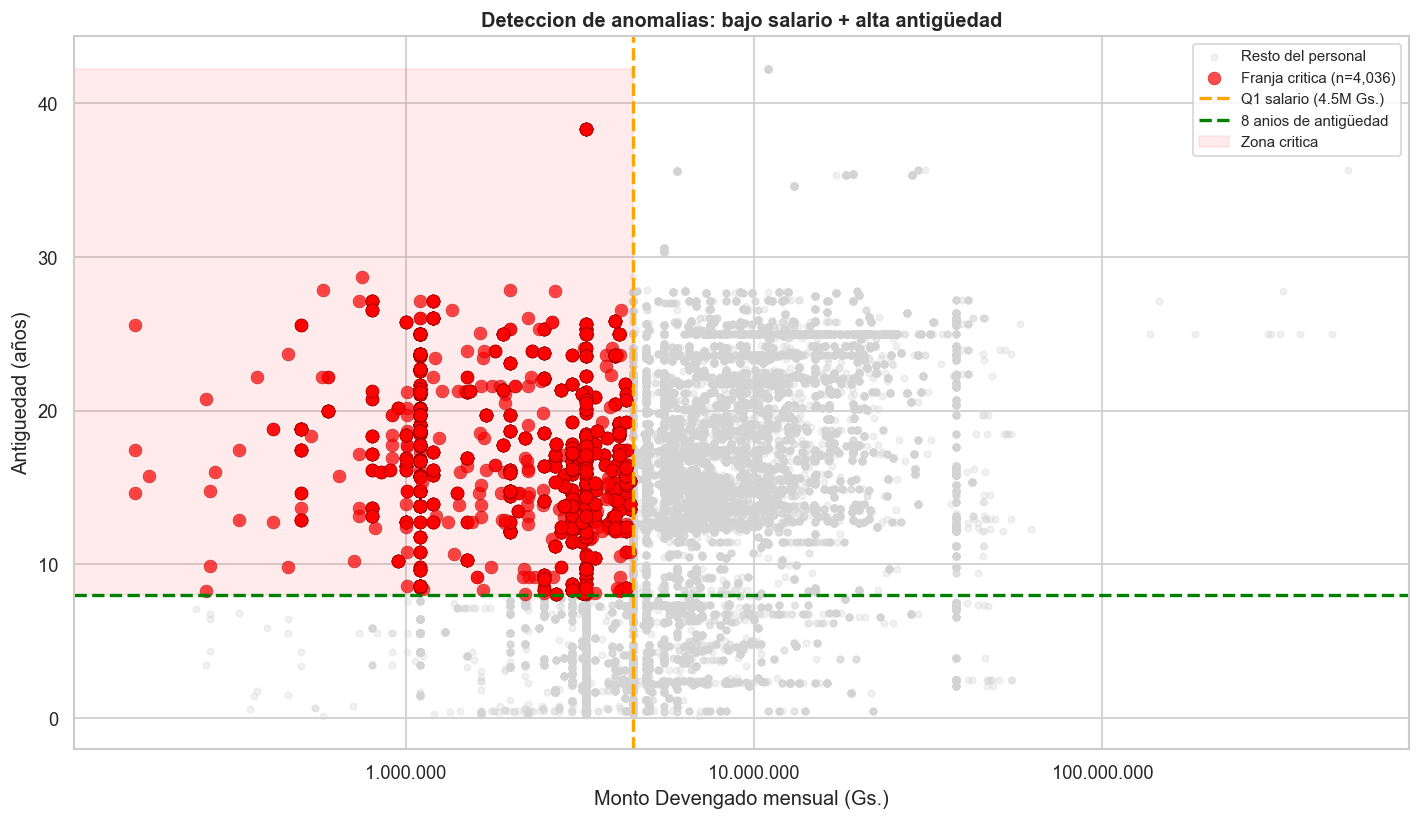

Umbral salario bajo (Q1)   : 4.50 M Gs.
Umbral antigüedad          : 8 años
Registros en franja critica: 4,036
Funcionarios unicos        : 397

--- Top 10 con menor ratio salario/antigüedad (posible inequidad) ---


,codigoPersona,cargo,tipoPersonal,monto_gs,antiguedad,ratio_sal_ant
1964,1342489,PROFESIONAL (II),COM,166666,25.587953,6268.477951
14890,3648933,PROFESIONAL (II),COM,166666,17.434634,9040.917313
4311,1773792,PROFESIONAL (II),COM,166666,14.617385,10671.824780
22792,4695507,MIEMBROS,COM,183332,15.712526,10969.736331
12432,3393309,PROFESIONAL (II),COM,266666,20.761123,12254.239172
28742,658562,ASESOR,CON,375000,22.157426,16193.509296
15067,3667245,PROFESIONAL (II),COM,283332,15.978097,16688.089176
21614,4537304,MIEMBROS,COM,275000,14.776181,17431.341924
9541,2600822,PROFESIONAL (II),COM,333332,17.415469,18100.652369
14106,3566299,MIEMBROS,COM,458332,23.690623,18562.998697


In [35]:
# Franja crítica: bajo salario + alta antigüedad
UMBRAL_SAL  = df_ml['monto_gs'].quantile(0.25)   # cuartil inferior
UMBRAL_ANT  = 8                                    # 8+ años en servicio

franja = df_ml[(df_ml['monto_gs'] < UMBRAL_SAL) & (df_ml['antiguedad'] >= UMBRAL_ANT)].copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Base gris
ax.scatter(df_ml['monto_gs'], df_ml['antiguedad'],
           color='lightgray', alpha=0.3, s=15, label='Resto del personal')

# Franja crítica en rojo
ax.scatter(franja['monto_gs'], franja['antiguedad'],
           color='red', s=60, alpha=0.7, edgecolors='darkred', linewidths=0.3,
           label=f'Franja critica (n={len(franja):,})')

# Líneas de umbral
ax.axvline(UMBRAL_SAL, color='orange', linestyle='--', linewidth=2,
           label=f'Q1 salario ({UMBRAL_SAL/1e6:.1f}M Gs.)')
ax.axhline(UMBRAL_ANT, color='green', linestyle='--', linewidth=2,
           label=f'{UMBRAL_ANT} anios de antigüedad')

# Zona sombreada
ax.fill_betweenx(y=[UMBRAL_ANT, df_ml['antiguedad'].max()],
                 x1=0, x2=UMBRAL_SAL,
                 alpha=0.08, color='red', label='Zona critica')

ax.set_xscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(fmt_gs))
ax.set_xlabel('Monto Devengado mensual (Gs.)')
ax.set_ylabel('Antiguedad (años)')
ax.set_title('Deteccion de anomalias: bajo salario + alta antigüedad', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Umbral salario bajo (Q1)   : {UMBRAL_SAL/1e6:.2f} M Gs.')
print(f'Umbral antigüedad          : {UMBRAL_ANT} años')
print(f'Registros en franja critica: {len(franja):,}')
print(f'Funcionarios unicos        : {franja["codigoPersona"].nunique():,}')

# Ratio salario/antigüedad — quiénes cobran poco respecto a su experiencia
df_ml['ratio_sal_ant'] = df_ml['monto_gs'] / (df_ml['antiguedad'] + 1)
print('\n--- Top 10 con menor ratio salario/antigüedad (posible inequidad) ---')
display(df_ml.sort_values('ratio_sal_ant').head(10)
        [['codigoPersona','cargo','tipoPersonal','monto_gs','antiguedad','ratio_sal_ant']])


## 5.2 — Análisis 2: K-Means + PCA — Detección de Anomalías por Objeto de Gasto

### Pregunta: ¿Qué perfiles de composición salarial existen y qué registros son anómalos?

Se utiliza como espacio de features la **composición de objetos de gasto** de cada registro (persona-mes): sueldo, dietas, bonificaciones, viáticos, etc.

Los registros más alejados de su centroide (distancia > P95) se marcan como anomalías.


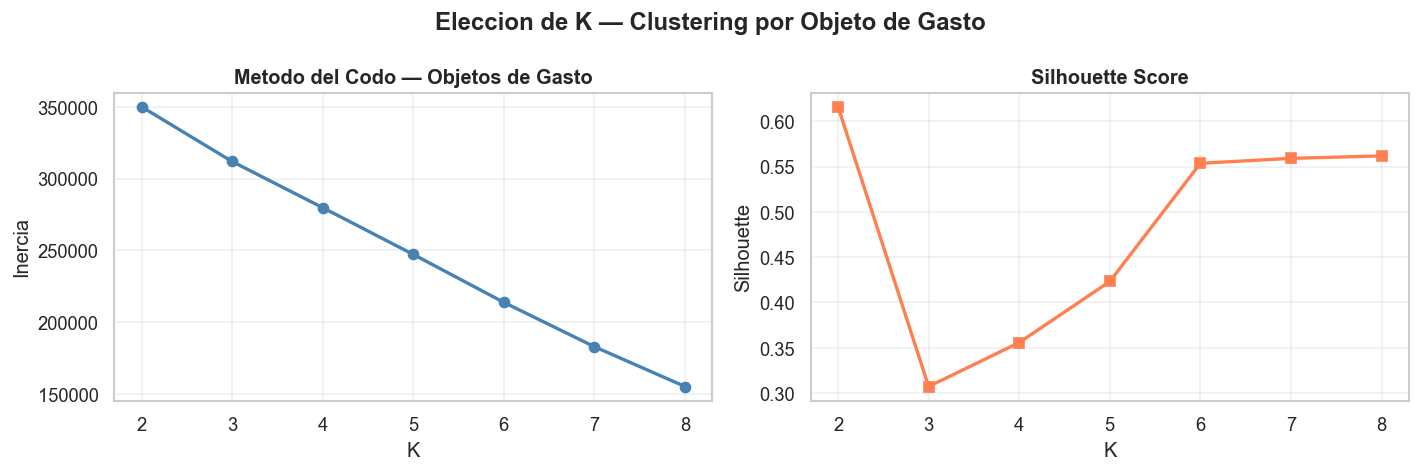

Silhouette por K:
  K=2: 0.6162
  K=3: 0.3072
  K=4: 0.3557
  K=5: 0.4232
  K=6: 0.5537
  K=7: 0.5592
  K=8: 0.5619


In [36]:
# Preparacion + Método del Codo + Silhouette para análisis 2
X_og    = pivot_base[COLS_OG].copy()
sc_og   = StandardScaler()
X_og_sc = sc_og.fit_transform(X_og)

inercias_og  = []
silhouettes  = []
K_range      = range(2, 9)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_og_sc)
    inercias_og.append(km.inertia_)
    silhouettes.append(silhouette_score(X_og_sc, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inercias_og, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Metodo del Codo — Objetos de Gasto', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inercia'); axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, 's-', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette'); axes[1].grid(alpha=0.3)

plt.suptitle('Eleccion de K — Clustering por Objeto de Gasto', fontweight='bold')
plt.tight_layout()
plt.show()

print('Silhouette por K:')
for k, s in zip(K_range, silhouettes):
    print(f'  K={k}: {s:.4f}')


In [37]:
# K-Means final análisis 2
K2 = 5  # ajustar según los gráficos anteriores

km2 = KMeans(n_clusters=K2, random_state=42, n_init=15)
pivot_base['cluster2'] = km2.fit_predict(X_og_sc)

# Distancia al centroide
centroides2  = km2.cluster_centers_
dist2        = np.linalg.norm(X_og_sc - centroides2[pivot_base['cluster2']], axis=1)
pivot_base['dist_centroide'] = dist2

print(f'K elegido: {K2}')
print('\nDistribucion por cluster:')
print(pivot_base['cluster2'].value_counts().sort_index().to_string())
print(f'\nDistancia centroide — P50: {np.percentile(dist2,50):.3f}  P95: {np.percentile(dist2,95):.3f}')


K elegido: 5

Distribucion por cluster:
cluster2
0     3150
1    18689
2      959
3     4435
4     3629

Distancia centroide — P50: 0.848  P95: 4.577


=== Perfil de gasto promedio por cluster (Gs.) ===


cluster2,0,1,2,3,4
sueldo,"11,389,048","6,155,313",0,0,0
dietas,0,756,"32,594,373",0,0
g_representacion,"1,880,803","4,755","5,361,366",0,0
aguinaldo,"338,336","788,651",0,"22,469","21,769"
rem_extraord,"217,431","12,912",0,95,364
sub_familiar,"263,502","11,630",0,0,0
bonificaciones,"2,462,826","359,593",0,802,"1,852"
gratificaciones,0,"107,438",0,0,0
contrat_salud,0,"6,260",0,0,0
jornales,0,612,0,"3,139,922",606


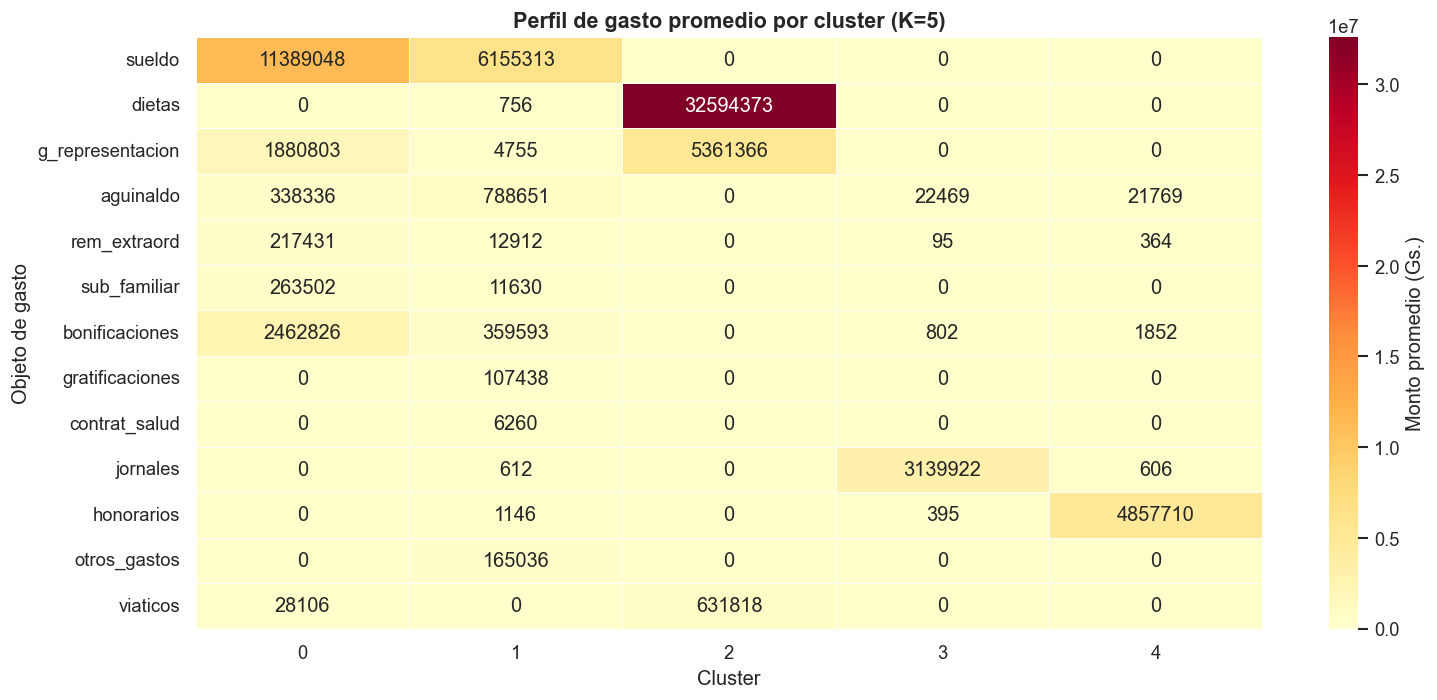


Composicion por tipo de personal:


tipoPersonal,COM,CON,PER
cluster2,,,
0,20,0,3130
1,2165,52,16472
2,0,0,959
3,0,4414,21
4,0,3615,14


In [38]:
# Perfil promedio de cada cluster — heatmap
perfil2 = pivot_base.groupby('cluster2')[COLS_OG + ['monto_total']].mean().round(0)

print('=== Perfil de gasto promedio por cluster (Gs.) ===')
pd.set_option('display.float_format', '{:,.0f}'.format)
display(perfil2[COLS_OG].T)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(perfil2[COLS_OG].T, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Monto promedio (Gs.)'})
ax.set_title(f'Perfil de gasto promedio por cluster (K={K2})', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Objeto de gasto')
plt.tight_layout()
plt.show()

# Composicion por tipo de personal
tipo_dist = pivot_base.groupby(['cluster2','tipoPersonal']).size().unstack(fill_value=0)
print('\nComposicion por tipo de personal:')
display(tipo_dist)


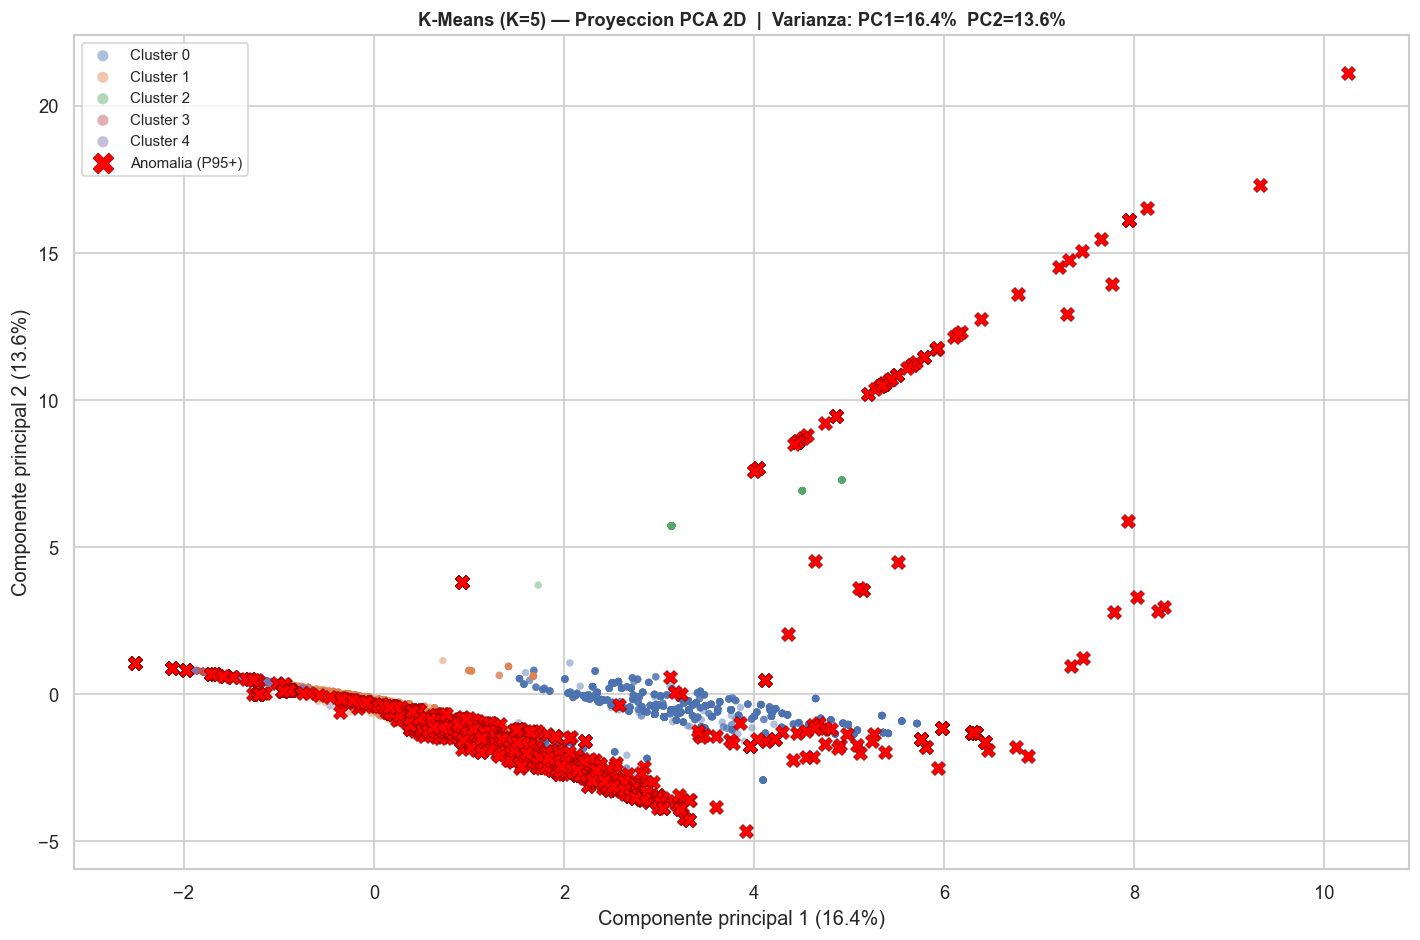

Umbral P95: 4.577
Registros anomalos: 1,550  (5.0% del total)


In [39]:
# PCA 2D + visualizacion de clusters y anomalias
UMBRAL_PCT = 95
umbral2    = np.percentile(pivot_base['dist_centroide'], UMBRAL_PCT)
pivot_base['es_anomalia'] = pivot_base['dist_centroide'] >= umbral2

pca2  = PCA(n_components=2, random_state=42)
X_2d  = pca2.fit_transform(X_og_sc)
pivot_base['pca_1'] = X_2d[:,0]
pivot_base['pca_2'] = X_2d[:,1]

COLORES2 = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C']
fig, ax  = plt.subplots(figsize=(12, 8))

for c in range(K2):
    mask = (pivot_base['cluster2']==c) & (~pivot_base['es_anomalia'])
    ax.scatter(pivot_base.loc[mask,'pca_1'], pivot_base.loc[mask,'pca_2'],
               c=COLORES2[c], label=f'Cluster {c}', alpha=0.45, s=20, edgecolors='none')

mask_a = pivot_base['es_anomalia']
ax.scatter(pivot_base.loc[mask_a,'pca_1'], pivot_base.loc[mask_a,'pca_2'],
           c='red', marker='X', s=70, label=f'Anomalia (P{UMBRAL_PCT}+)',
           edgecolors='darkred', linewidths=0.4, zorder=5)

titulo = (f'K-Means (K={K2}) — Proyeccion PCA 2D  |  '
          f'Varianza: PC1={pca2.explained_variance_ratio_[0]:.1%}  '
          f'PC2={pca2.explained_variance_ratio_[1]:.1%}')
ax.set_title(titulo, fontsize=11, fontweight='bold')
ax.set_xlabel(f'Componente principal 1 ({pca2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'Componente principal 2 ({pca2.explained_variance_ratio_[1]:.1%})')
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.show()

print(f'Umbral P{UMBRAL_PCT}: {umbral2:.3f}')
print(f'Registros anomalos: {mask_a.sum():,}  ({mask_a.mean()*100:.1f}% del total)')


In [40]:
# Top 20 registros mas alejados de su centroide
cols_vista = ['codigoPersona','mes','cluster2','dist_centroide',
              'tipoPersonal','cargo','monto_total'] + COLS_OG[:5]

anomalias_top = (
    pivot_base[pivot_base['es_anomalia']][cols_vista]
    .sort_values('dist_centroide', ascending=False)
    .head(20)
)

pd.set_option('display.float_format', '{:,.0f}'.format)
print(f'TOP 20 registros mas anomalos (mayor distancia a su centroide):')
display(anomalias_top)


TOP 20 registros mas anomalos (mayor distancia a su centroide):


,codigoPersona,mes,cluster2,dist_centroide,tipoPersonal,cargo,monto_total,sueldo,dietas,g_representacion,aguinaldo,rem_extraord
30731,962676,7,1,86,PER,DIRECTOR GENERAL,507592800,0,0,0,0,0
27891,594380,7,1,78,PER,COORDINADOR,457708265,0,0,0,0,0
29955,813905,7,1,62,PER,ASESOR,368784000,0,0,0,0,0
30018,826438,7,1,56,PER,DIRECTOR GENERAL,330960000,0,0,0,0,0
2505,1439279,7,1,55,PER,ASESOR,324093000,0,0,0,0,0
2225,1399887,7,1,52,PER,DIRECTOR,305250000,0,0,0,0,0
1002,1171504,7,1,51,PER,ASESOR,299700000,0,0,0,0,0
9805,2837734,10,2,50,PER,MIEMBROS,62503253,0,32606840,5293160,0,0
789,1135789,3,2,35,PER,MIEMBROS,55182328,0,32606840,5293160,0,0
16941,3864656,12,1,34,CON,PROFESIONAL SUPERIOR (I),4500000,0,0,0,0,0


## Conclusiones — Etapa 5: Clustering

### Análisis 1: Antigüedad vs. Salario (K=4)

| Cluster | Perfil | Descripción |
|---|---|---|
| **Alto salario + Baja antigüedad** | Diputados / Directivos nuevos | Altos sueldos desde el inicio (electos o designados políticos) |
| **Alto salario + Alta antigüedad** | Directivos veteranos | Carrera consolidada con bonificaciones acumuladas |
| **Bajo salario + Alta antigüedad** | Técnicos rezagados | Veteranos con salario estancado — franja crítica |
| **Bajo salario + Baja antigüedad** | Contratados/Jornaleros | Personal de apoyo reciente |

**Franja crítica identificada**: funcionarios con 8+ años de servicio y salario en el cuartil inferior — candidatos a revisión de escalafón.

### Análisis 2: Objetos de Gasto + PCA (K=5)

| Cluster | Perfil | Concepto dominante |
|---|---|---|
| 0 | Personal técnico-administrativo | Sueldo (111) |
| 1 | Asesores y profesionales | Sueldo + Bonificaciones (133) |
| 2 | Diputados (MIEMBROS) | Dietas (112) |
| 3 | Contratados/Jornaleros | Honorarios (145) o Jornales (144) |
| 4 | Directivos | Sueldo alto + múltiples bonificaciones |

**Anomalías (P95)**: pagos extraordinarios de julio (bonificaciones anuales >400M Gs.), viáticos atípicos y meses de aguinaldo proporcional.


---
# CONCLUSIONES GENERALES

## Resumen del pipeline — Nómina Cámara de Diputados 2025

### 1. Estructura del gasto
La Cámara de Diputados destinó en 2025 aproximadamente **240–280 mil millones de guaraníes** en remuneraciones anuales. El gasto salarial es predecible y concentrado: los diputados (MIEMBROS), directores generales y asesores senior representan el 10% del personal pero el ~40% del gasto (Gini ≈ 0.55–0.60).

### 2. Desigualdad y brecha de género
El **Índice de Gini** calculado (~0.55) refleja una desigualdad moderada-alta, consistente con instituciones con mezcla de electos y personal técnico. La brecha salarial por sexo (~10–15% en mediana anual) opera principalmente vía la distribución de cargos, no directamente por el sexo.

### 3. Modelos supervisados
- **Clasificación (RF)**: ROC-AUC = 0.93 — el sistema salarial es altamente predecible por cargo y tipo de contrato.
- **Regresión (RF)**: R² = 0.87 — el `codigoObjetoGasto` y el cargo son los predictores dominantes del monto devengado.
- Ambos modelos superan significativamente al baseline, validando que la estructura salarial tiene lógica interna consistente.

### 4. Segmentación (Clustering)
Los dos análisis K-Means identificaron perfiles complementarios:
- Por **antigüedad/salario**: 4 grupos claros, incluyendo una franja crítica de veteranos mal pagados.
- Por **composición de gasto**: 5 grupos, donde los diputados forman un cluster casi puro (dietas vs. sueldo).

### 5. Outliers y alertas principales
| Tipo | Detalle |
|---|---|
| **Pago máximo** | 507.6M Gs. en un único registro (Director General, mes 7) — bonificación extraordinaria |
| **Franja crítica** | Técnicos con 8+ años y salario < Q1 — candidatos a revisión de escala salarial |
| **Anomalías P95** | Pagos en julio y diciembre con patrones atípicos en la composición de objetos de gasto |
| **Corte 13** | 3,765 registros de aguinaldo/ajuste anual (mes=13) — permanecen en el dataset pero se excluyen de los cálculos de masa salarial para evitar doble conteo |

### 6. Recomendaciones
1. **Transparencia**: Publicar desagregado los pagos bajo código 199 (Otros Gastos del Personal).
2. **Equidad**: Revisar escala salarial de técnicos permanentes con alta antigüedad y bajo salario.
3. **Monitoreo**: Implementar detección de anomalías mensual usando el modelo de distancia a centroide.
